# Projeto Final — Machine Learning e Visão Computacional

## Predição de Risco de Crédito

### Objetivo do projeto

Este projeto tem como objetivo desenvolver um pipeline completo de Machine Learning capaz de prever o risco de inadimplência de clientes de uma instituição financeira.

A variável alvo utilizada será `loan_status`:

- `0`: cliente adimplente;
- `1`: cliente inadimplente.

O desenvolvimento seguirá as seguintes etapas:

1. Coleta dos Dados

2. Limpeza Estrutural e Exploração

3. Tratamento e Limpeza dos Dados

4. Feature Engineeting

5. Divisão dos Dados
 
6. Pré-processamento

7. Modelagem

8. Avaliação Final

9. Veredito Final


Os algoritmos avaliados serão o K-Nearest Neighbors (KNN) e a Árvore de Decisão.

# 1. Coleta de Dados

Nesta etapa serão realizadas a importação das bibliotecas, a leitura da base de dados e uma inspeção inicial do conjunto de dados.

Nenhuma transformação ou exclusão será realizada neste momento. O objetivo é apenas verificar se a base foi carregada corretamente e compreender sua estrutura inicial.

## 1.1 Importação das Bibliotecas

In [329]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")

# Configuração para exibir todas as colunas do DataFrame
pd.set_option("display.max_columns", None)

#importando ferramentas de machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

#importando ferramentas de avaliação de modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## 1.2 Carregamento da Base de Dados

A base original está armazenada na pasta `data/raw`, preservando os dados brutos sem alterações.

O arquivo será carregado com a biblioteca Pandas e armazenado em um DataFrame chamado `df`.

In [330]:
# =====================================================
# Carregamento da base de dados
# =====================================================


# Caminho relativo do arquivo CSV
caminho_dados = "../data/raw/credit_risk_dataset.csv"

# Carregamento da base
df = pd.read_csv(caminho_dados)
print("Base carregada com sucesso!")

Base carregada com sucesso!


## 1.3 Inspeção Inicial dos Registros

In [331]:
print("Primeiros registros:")
display(df.head())
print("Ultimos registros:")
display(df.tail())
print("Registros aleatórios:")
display(df.sample(5, random_state=42))



Primeiros registros:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Ultimos registros:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


Registros aleatórios:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
14668,24,28000,OWN,6.0,HOMEIMPROVEMENT,B,10000,10.37,0,0.36,N,2
24614,27,64000,RENT,0.0,PERSONAL,C,10000,15.27,0,0.16,Y,10
11096,26,72000,MORTGAGE,10.0,EDUCATION,D,16000,NaN,0,0.22,N,3
10424,23,27996,RENT,7.0,DEBTCONSOLIDATION,A,10000,NaN,1,0.36,N,2
26007,30,44500,RENT,2.0,MEDICAL,E,13000,16.32,1,0.29,N,6


## 1.4 Dimensões do Dataset

In [332]:
linhas, colunas = df.shape
print(f"Quantidade de linhas : {linhas}")
print(f"Quantidade de colunas: {colunas}")


Quantidade de linhas : 32581
Quantidade de colunas: 12


## 1.5 Variáveis Disponíveis

In [333]:

for coluna in df.columns:
    print(coluna)

person_age
person_income
person_home_ownership
person_emp_length
loan_intent
loan_grade
loan_amnt
loan_int_rate
loan_status
loan_percent_income
cb_person_default_on_file
cb_person_cred_hist_length


### Primeiras observações

Após o carregamento da base foi possível verificar que o dataset contém informações relacionadas ao perfil financeiro dos clientes e às características dos empréstimos concedidos.

As variáveis incluem informações demográficas, renda anual, finalidade do empréstimo, classificação de crédito, taxa de juros e histórico financeiro.

A variável **loan_status** representa o alvo do problema de classificação, indicando se o cliente tornou-se inadimplente (1) ou permaneceu adimplente (0).

Nesta etapa foi confirmado que o arquivo foi carregado corretamente e que a estrutura da base está íntegra para prosseguirmos com a análise exploratória.

## 1.6 Auditoria Técnica Inicial

Antes de iniciar a análise exploratória é necessário compreender a estrutura interna do conjunto de dados.

Nesta etapa serão analisados:

- estrutura da base
- tipos das variáveis
- valores ausentes
- consistência dos dados

In [334]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [335]:

df.dtypes.value_counts()
#permite prever o trabalho futuro, quantos Encoding precisaremos por exemplo

int64      5
str        4
float64    3
Name: count, dtype: int64

In [336]:
tipos = pd.DataFrame({

"Tipo":df.dtypes,

"Nulos":df.isnull().sum(),

"Percentual Nulos":round(df.isnull().mean()*100,2)

})

tipos

,Tipo,Nulos,Percentual Nulos
person_age,int64,0,0.00
person_income,int64,0,0.00
person_home_ownership,str,0,0.00
person_emp_length,float64,895,2.75
loan_intent,str,0,0.00
loan_grade,str,0,0.00
loan_amnt,int64,0,0.00
loan_int_rate,float64,3116,9.56
loan_status,int64,0,0.00
loan_percent_income,float64,0,0.00


### Análise da Auditoria Técnica

A auditoria técnica permitiu compreender a estrutura geral do conjunto de dados.

Foi possível identificar variáveis numéricas inteiras, variáveis numéricas contínuas e variáveis categóricas.

Também foram observadas colunas contendo valores ausentes, indicando que será necessária uma etapa de tratamento antes do treinamento dos modelos.

As variáveis categóricas deverão ser convertidas para representação numérica durante a fase de pré-processamento utilizando técnicas de Encoding.

Essa inspeção confirmou que a base apresenta estrutura compatível com problemas de classificação supervisionada.

# 2. Limpeza Estrutural e Exploração dos Dados

Nesta etapa será realizada uma investigação detalhada da qualidade dos dados.

O objetivo é compreender a distribuição das variáveis, identificar inconsistências e definir quais tratamentos serão necessários antes da construção dos modelos de Machine Learning.

## 2.1 - Detecção de valores duplicados

In [337]:
duplicados = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 165


### Investigação de Registros Duplicados

Foi realizada uma inspeção para identificar registros completamente duplicados na base de dados.

Registros duplicados podem introduzir viés estatístico, aumentando artificialmente a frequência de determinados perfis de clientes e influenciando o treinamento dos algoritmos.

Nesta etapa foi identificado o total de registros duplicados, cuja remoção será realizada apenas após a confirmação de que representam redundâncias reais.

## 2.2 - Detecção de valores Nulos

In [338]:
nulos = pd.DataFrame({

"Quantidade":df.isnull().sum(),

"Percentual":round(df.isnull().mean()*100,2)

})

nulos

,Quantidade,Percentual
person_age,0,0.00
person_income,0,0.00
person_home_ownership,0,0.00
person_emp_length,895,2.75
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_int_rate,3116,9.56
loan_status,0,0.00
loan_percent_income,0,0.00


### Investigação de Valores Ausentes

Foi realizada uma inspeção para identificar a presença de valores ausentes no conjunto de dados.

Os resultados permitirão definir, posteriormente, a estratégia de tratamento mais adequada para cada variável, considerando sua distribuição estatística e o impacto no treinamento dos modelos.

Nesta etapa nenhuma imputação foi realizada, pois o objetivo é apenas compreender a qualidade dos dados.

## 2.3 Análise Descritiva e Estatística

Nesta etapa será realizada uma análise estatística das variáveis presentes no conjunto de dados.

O objetivo é compreender a dimensão da base, os tipos das variáveis, as medidas de tendência central, a dispersão dos dados, os valores mínimos e máximos e os quartis.

Essa análise será utilizada para identificar possíveis assimetrias, inconsistências e indícios de valores extremos antes da construção dos gráficos exploratórios.

### Sumário Estatístico das Variáveis Numéricas

O método `describe()` será utilizado para calcular as principais medidas estatísticas das variáveis numéricas, incluindo média, desvio-padrão, mínimo, máximo e quartis.

In [339]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


### Sumário Estatístico das Variáveis Categóricas

As variáveis categóricas serão analisadas por meio da quantidade de valores preenchidos, número de categorias distintas, categoria mais frequente e frequência da categoria predominante.

In [340]:
df.describe(include="object").T

C:\Users\maycon.valer\AppData\Local\Temp\ipykernel_3192\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836


In [341]:
auditoria_estatistica = pd.DataFrame({
    "tipo_dado": df.dtypes,
    "quantidade_preenchida": df.notna().sum(),
    "quantidade_nulos": df.isna().sum(),
    "percentual_nulos": (df.isna().mean() * 100).round(2),
    "quantidade_unicos": df.nunique()
})

auditoria_estatistica

,tipo_dado,quantidade_preenchida,quantidade_nulos,percentual_nulos,quantidade_unicos
person_age,int64,32581,0,0.00,58
person_income,int64,32581,0,0.00,4295
person_home_ownership,str,32581,0,0.00,4
person_emp_length,float64,31686,895,2.75,36
loan_intent,str,32581,0,0.00,6
loan_grade,str,32581,0,0.00,7
loan_amnt,int64,32581,0,0.00,753
loan_int_rate,float64,29465,3116,9.56,348
loan_status,int64,32581,0,0.00,2
loan_percent_income,float64,32581,0,0.00,77


### Decisão do Cientista de Dados — Análise Descritiva e Estatística

A análise desritiva demostra como os dados realmente se apresentam, enquando a estatística demonstra como eles de relacionam entre si

A análise descritiva confirmou que o conjunto de dados possui variáveis numéricas e categóricas relacionadas ao perfil dos clientes e às características dos empréstimos.

Na Análise estatística, a comparação entre média, mediana, quartis e valores máximos revelou que algumas variáveis apresentam valores máximos muito superiores ao terceiro quartil. Esse comportamento representa um indício de assimetria e possível presença de outliers.

As variáveis categóricas possuem um número limitado de categorias e deverão ser convertidas para formato numérico durante a etapa de pré-processamento.

As colunas com valores ausentes ainda não serão tratadas. A escolha entre média e mediana será realizada após a análise visual das distribuições, considerando que a média é sensível a valores extremos, enquanto a mediana é mais robusta.

Nenhum registro foi removido ou transformado nesta etapa.

## 2.4 Distribuição da Variável Alvo

Antes da construção dos modelos de Machine Learning é necessário compreender a distribuição das classes da variável alvo.

Essa análise permitirá verificar se existe desbalanceamento entre clientes adimplentes e inadimplentes, justificando posteriormente a aplicação de técnicas de balanceamento durante o treinamento dos modelos.

In [342]:
distribuicao = pd.DataFrame({

"Quantidade":df["loan_status"].value_counts(),

"Percentual":round(df["loan_status"].value_counts(normalize=True)*100,2)

})

distribuicao

,Quantidade,Percentual
loan_status,,
0,25473,78.18
1,7108,21.82


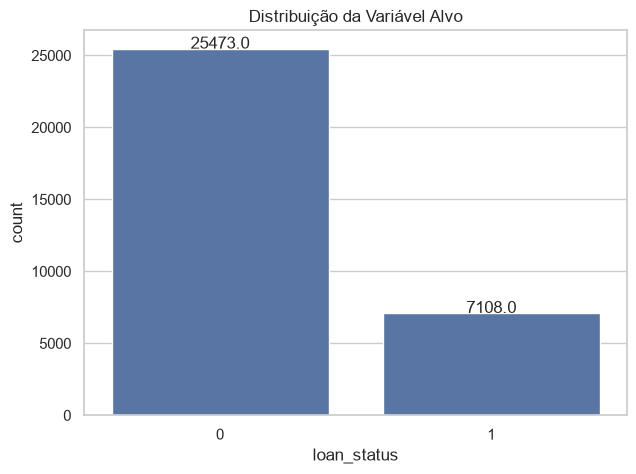

In [343]:
plt.figure(figsize=(7,5))

ax = sns.countplot(

data=df,

x="loan_status"

)

for barra in ax.patches:

    altura = barra.get_height()

    ax.text(

        barra.get_x()+barra.get_width()/2,

        altura,

        f"{altura}",

        ha="center"

    )

plt.title("Distribuição da Variável Alvo")

plt.show()

### Análise da Variável Alvo

Observa-se que a variável `loan_status` apresenta distribuição desbalanceada entre as classes.

A maior parte dos registros corresponde a clientes adimplentes (`loan_status = 0`), enquanto a classe dos clientes inadimplentes (`loan_status = 1`) representa uma parcela significativamente menor da base.

Esse comportamento poderá influenciar negativamente o treinamento dos algoritmos, levando o modelo a favorecer a classe majoritária.

Para evitar esse problema, será aplicada posteriormente uma técnica de balanceamento de classes (SMOTE), exclusivamente sobre os dados de treinamento, evitando Data Leakage.

## 2.5 Análise Visual das Distribuições

Após a análise estatística descritiva, será realizada uma análise gráfica das variáveis numéricas utilizando histogramas.

O objetivo é compreender o comportamento das distribuições, identificar possíveis assimetrias e levantar evidências para orientar o tratamento dos dados nas próximas etapas do pipeline.

### Funções Auxiliares para Visualização

In [344]:
def plotar_histograma(dataframe, coluna, bins=30):
    """
    Plota o histograma de uma variável numérica.

    Parâmetros:
    dataframe : DataFrame contendo os dados.
    coluna : Nome da variável.
    bins : Quantidade de intervalos do histograma.
    """

    plt.figure(figsize=(8,5))

    plt.hist(
        dataframe[coluna].dropna(),
        bins=bins,
        edgecolor="black"
    )

    plt.title(f"Distribuição de {coluna}", fontsize=14)

    plt.xlabel(coluna)

    plt.ylabel("Frequência")

    plt.grid(axis="y", alpha=0.3)

    plt.show()

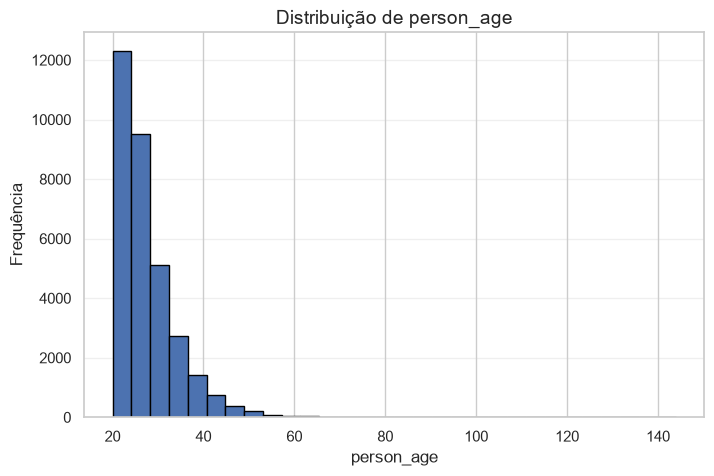

In [345]:
plotar_histograma(df, "person_age")

### Análise da variável `person_age`

A distribuição das idades apresenta forte concentração entre aproximadamente 20 e 35 anos, indicando que a maior parte dos clientes pertence à população adulta jovem.

Observa-se uma cauda à direita, com poucos registros em idades mais elevadas, caracterizando uma distribuição assimétrica positiva.

Também foram identificados valores muito superiores à maioria da população, sugerindo possíveis outliers ou inconsistências cadastrais. Esses registros serão investigados posteriormente por meio de boxplots e do método do Intervalo Interquartil (IQR).

Nesta etapa, nenhum registro foi removido ou alterado.

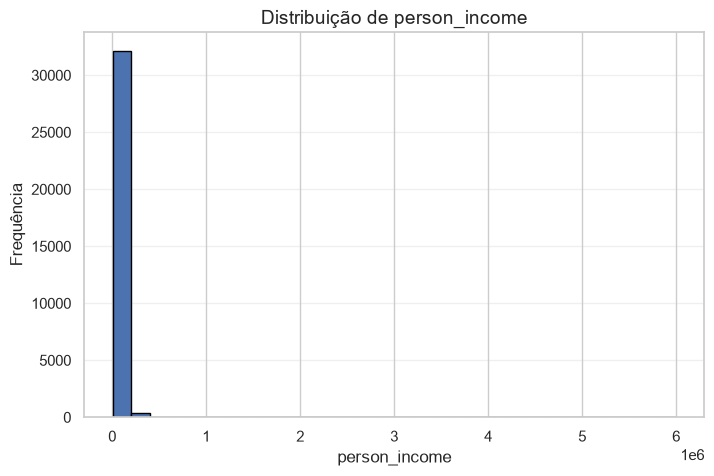

In [346]:
plotar_histograma(df, "person_income")

Para facilitar a interpretação da concentração principal dos dados, o histograma foi limitado visualmente ao percentil 99. Nenhum registro foi removido da base nesta etapa.

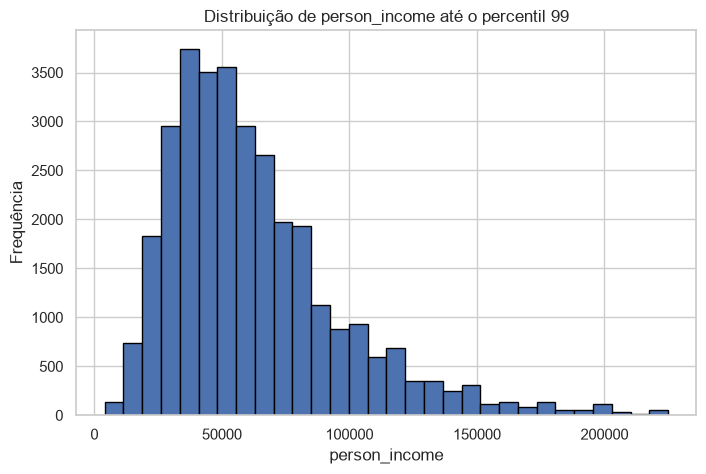

In [347]:
limite_visual = df["person_income"].quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[df["person_income"] <= limite_visual, "person_income"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribuição de person_income até o percentil 99")
plt.xlabel("person_income")
plt.ylabel("Frequência")
plt.show()

### Análise da variável `person_income`

Para facilitar a interpretação da distribuição principal, o histograma foi limitado ao percentil 99 apenas para fins de visualização, sem qualquer alteração na base de dados.

Observa-se concentração da maior parte das rendas entre aproximadamente 25 mil e 80 mil, acompanhada por uma cauda extensa à direita.

Esse comportamento caracteriza forte assimetria positiva, indicando a presença de poucos clientes com rendas significativamente superiores à maioria.

Caso seja necessário realizar imputação de valores ausentes, a mediana tende a representar melhor a distribuição do que a média, por ser menos influenciada por valores extremos.

Os possíveis outliers serão avaliados posteriormente utilizando boxplots e o método IQR.

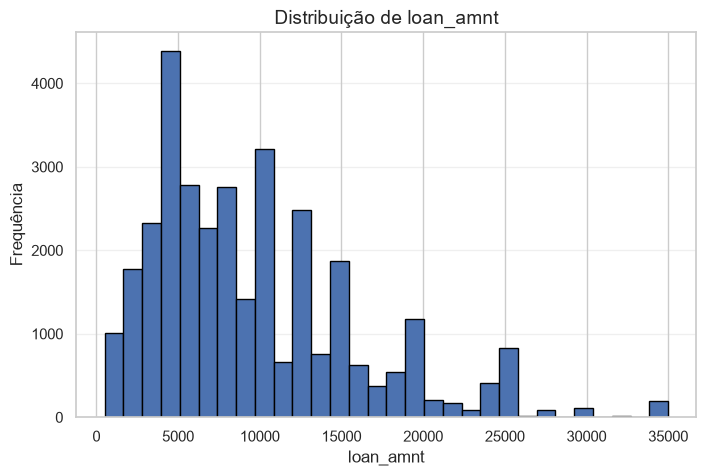

In [348]:
plotar_histograma(df, "loan_amnt")

### Análise da variável `loan_amnt`

Os valores de empréstimo apresentam maior concentração entre aproximadamente 3 mil e 15 mil, indicando que a instituição financeira concede predominantemente operações de pequeno e médio porte.

A distribuição apresenta uma cauda à direita, evidenciando a existência de empréstimos de maior valor, porém em quantidade significativamente menor.

Também foram observadas concentrações em faixas específicas de valores, sugerindo que o banco pode adotar limites padronizados para concessão de crédito.

Os valores mais elevados serão investigados posteriormente por meio de boxplots e do método IQR para verificar se representam operações legítimas ou possíveis valores extremos.

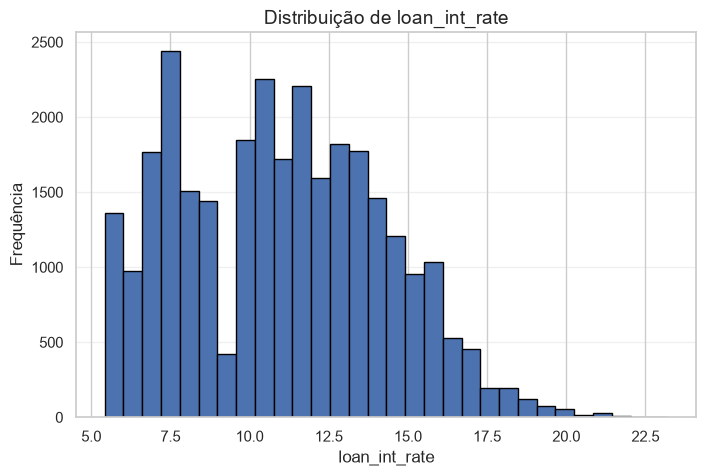

In [349]:
plotar_histograma(df, "loan_int_rate")

### Análise da variável `loan_int_rate`

A distribuição das taxas de juros apresenta maior concentração entre aproximadamente 7% e 15%.

Observa-se uma cauda à direita, indicando que alguns empréstimos possuem taxas superiores à média da população.

Embora existam registros próximos de 20% a 23%, esses valores podem representar operações de crédito destinadas a clientes com maior risco e, portanto, não devem ser considerados automaticamente como inconsistências.

A confirmação da presença de outliers será realizada posteriormente por meio dos boxplots e do método IQR.

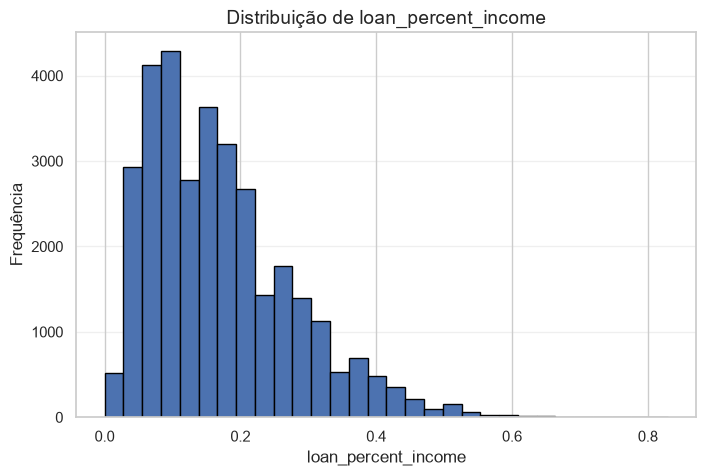

In [350]:
plotar_histograma(df, "loan_percent_income")

### Análise da variável `loan_percent_income`

A maior parte dos clientes compromete entre aproximadamente 5% e 25% da renda com o pagamento do empréstimo.

A distribuição apresenta uma cauda à direita, indicando que alguns clientes possuem um comprometimento significativamente superior ao restante da população.

Esses valores elevados não devem ser tratados automaticamente como inconsistências, pois podem representar justamente clientes com maior probabilidade de inadimplência.

Essa característica torna a variável potencialmente importante para os modelos de classificação.

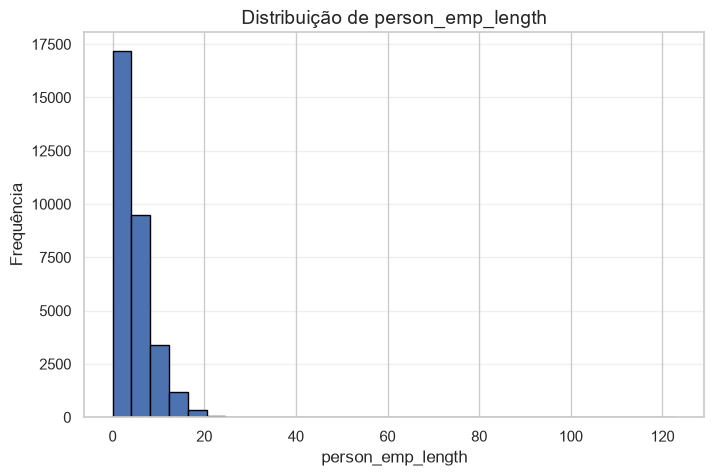

In [351]:
plotar_histograma(df, "person_emp_length")

### Análise da variável `person_emp_length`

Observa-se que a maior parte dos clientes possui entre 0 e 10 anos de experiência profissional.

A distribuição apresenta forte assimetria positiva, acompanhada por poucos registros extremamente elevados.

Alguns valores observados ultrapassam limites plausíveis para tempo de experiência profissional, sugerindo possíveis inconsistências cadastrais.

Esses registros serão avaliados posteriormente utilizando boxplots e o método IQR antes da definição da estratégia de tratamento.

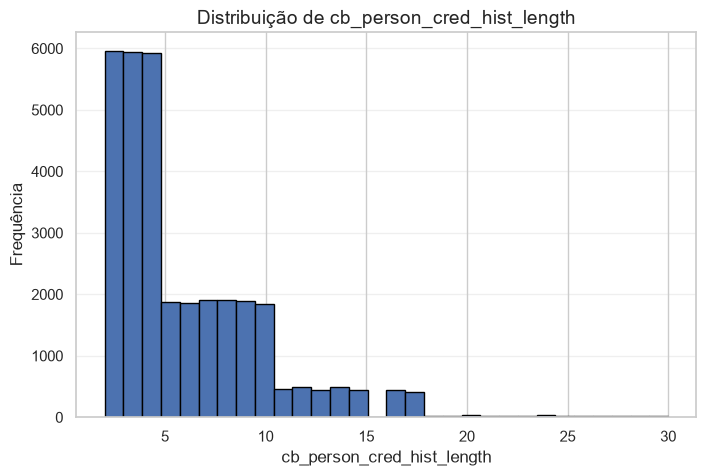

In [352]:
plotar_histograma(df, "cb_person_cred_hist_length")

### Análise da variável `cb_person_cred_hist_length`

A maior parte dos clientes apresenta histórico de crédito entre aproximadamente 2 e 10 anos.

A distribuição apresenta uma cauda à direita, indicando que alguns clientes possuem relacionamento bancário significativamente mais longo.

Embora existam poucos registros superiores a 20 anos, esses valores são compatíveis com clientes de maior idade e não representam, neste momento, indícios claros de inconsistências.

A confirmação da presença de valores extremos será realizada posteriormente utilizando boxplots e o método IQR.

### Tabela de hipóteses das distribuições

A tabela a seguir combina medidas estatísticas calculadas automaticamente com interpretações obtidas a partir dos histogramas.

As hipóteses ainda são provisórias e serão confirmadas ou refutadas nas próximas etapas por meio de boxplots e do método do Intervalo Interquartil (IQR).

In [353]:
variaveis_analisadas = [
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "person_emp_length",
    "cb_person_cred_hist_length"
]


def classificar_assimetria(valor):
    valor_absoluto = abs(valor)

    if valor_absoluto < 0.5:
        return "Baixa"
    elif valor_absoluto < 1:
        return "Moderada"
    else:
        return "Elevada"


analise_distribuicoes = pd.DataFrame({
    "Variável": variaveis_analisadas,

    "Média": [
        df[coluna].mean()
        for coluna in variaveis_analisadas
    ],

    "Mediana": [
        df[coluna].median()
        for coluna in variaveis_analisadas
    ],

    "Assimetria calculada": [
        df[coluna].skew()
        for coluna in variaveis_analisadas
    ],

    "Mínimo": [
        df[coluna].min()
        for coluna in variaveis_analisadas
    ],

    "Máximo": [
        df[coluna].max()
        for coluna in variaveis_analisadas
    ],

    "Distribuição observada": [
        "Concentrada entre 20 e 35 anos",
        "Concentrada entre 25 mil e 80 mil",
        "Concentrada entre 3 mil e 15 mil",
        "Concentrada entre 7% e 15%",
        "Concentrada entre 5% e 25% da renda",
        "Concentrada entre 0 e 10 anos",
        "Concentrada entre 2 e 10 anos"
    ],

    "Evidências observadas": [
        "Cauda à direita e idades muito superiores à concentração principal",
        "Cauda longa e valores máximos extremamente elevados",
        "Cauda à direita e picos em valores padronizados",
        "Cauda à direita e poucas taxas superiores a 20%",
        "Cauda à direita e poucos clientes com alto comprometimento",
        "Cauda longa e valores acima dos limites plausíveis",
        "Cauda à direita, porém valores altos ainda plausíveis"
    ],

    "Hipótese inicial": [
        "Investigar possíveis inconsistências cadastrais",
        "Usar mediana para imputação e investigar outliers",
        "Confirmar outliers com boxplot e IQR",
        "Usar mediana para imputação e confirmar possíveis outliers",
        "Manter valores altos até avaliar relação com inadimplência",
        "Usar mediana e tratar valores inconsistentes",
        "Manter valores e confirmar comportamento com boxplot"
    ]
})


analise_distribuicoes["Classificação automática"] = (
    analise_distribuicoes["Assimetria calculada"]
    .apply(classificar_assimetria)
)


analise_distribuicoes = analise_distribuicoes[
    [
        "Variável",
        "Média",
        "Mediana",
        "Assimetria calculada",
        "Classificação automática",
        "Mínimo",
        "Máximo",
        "Distribuição observada",
        "Evidências observadas",
        "Hipótese inicial"
    ]
]


display(
    analise_distribuicoes.round(2)
)

,Variável,Média,Mediana,Assimetria calculada,Classificação automática,Mínimo,Máximo,Distribuição observada,Evidências observadas,Hipótese inicial
0,person_age,27.73,26.00,2.58,Elevada,20.00,144.00,Concentrada entre 20 e 35 anos,Cauda à direita e idades muito superiores à co...,Investigar possíveis inconsistências cadastrais
1,person_income,66074.85,55000.00,32.87,Elevada,4000.00,6000000.00,Concentrada entre 25 mil e 80 mil,Cauda longa e valores máximos extremamente ele...,Usar mediana para imputação e investigar outliers
2,loan_amnt,9589.37,8000.00,1.19,Elevada,500.00,35000.00,Concentrada entre 3 mil e 15 mil,Cauda à direita e picos em valores padronizados,Confirmar outliers com boxplot e IQR
3,loan_int_rate,11.01,10.99,0.21,Baixa,5.42,23.22,Concentrada entre 7% e 15%,Cauda à direita e poucas taxas superiores a 20%,Usar mediana para imputação e confirmar possív...
4,loan_percent_income,0.17,0.15,1.06,Elevada,0.00,0.83,Concentrada entre 5% e 25% da renda,Cauda à direita e poucos clientes com alto com...,Manter valores altos até avaliar relação com i...
5,person_emp_length,4.79,4.00,2.61,Elevada,0.00,123.00,Concentrada entre 0 e 10 anos,Cauda longa e valores acima dos limites plausí...,Usar mediana e tratar valores inconsistentes
6,cb_person_cred_hist_length,5.80,4.00,1.66,Elevada,2.00,30.00,Concentrada entre 2 e 10 anos,"Cauda à direita, porém valores altos ainda pla...",Manter valores e confirmar comportamento com b...


## 2.6 Análise Visual de Outliers

Após a análise das distribuições, serão utilizados boxplots para identificar valores extremos nas variáveis numéricas.

O objetivo é verificar quais observações se encontram fora do comportamento predominante da base e avaliar se representam erros, casos legítimos ou informações importantes para o problema de negócio.

Nenhum valor será removido nesta etapa.

### Função Auxiliar para Boxplots

In [354]:
def plotar_boxplot(dataframe, coluna):
    """
    Plota um boxplot horizontal para uma variável numérica.

    Parâmetros:
    dataframe: DataFrame contendo os dados.
    coluna: nome da variável numérica.
    """

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        x=dataframe[coluna]
    )

    plt.title(f"Boxplot de {coluna}")
    plt.xlabel(coluna)

    plt.show()

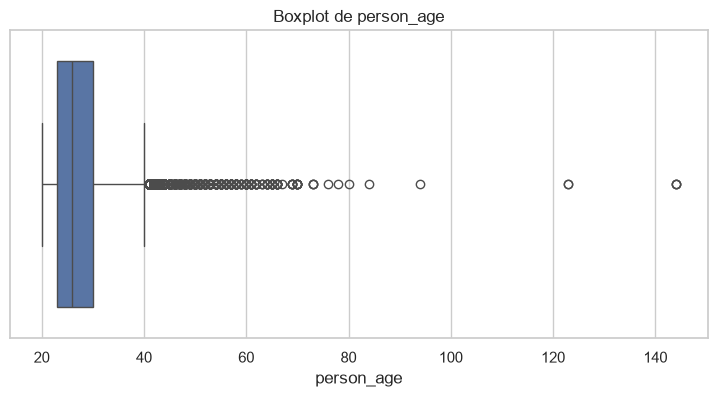

In [355]:
plotar_boxplot(df, "person_age")

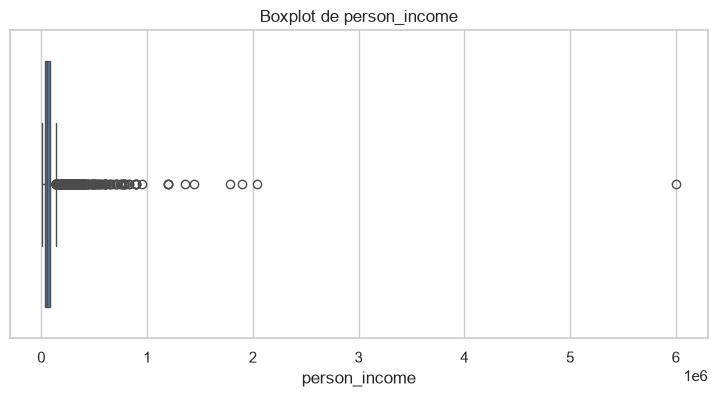

In [356]:
plotar_boxplot(df, "person_income")

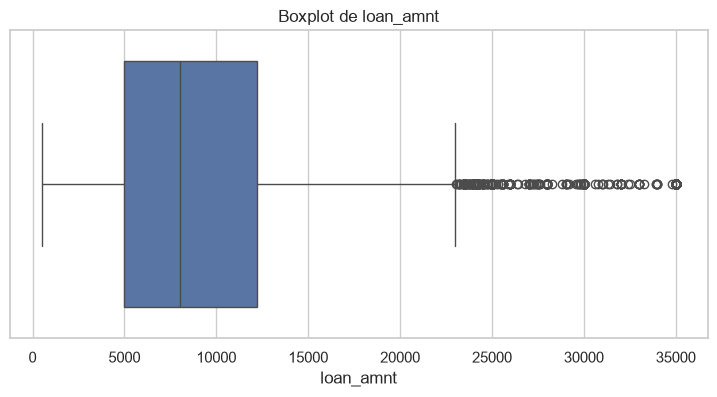

In [357]:
plotar_boxplot(df, "loan_amnt")

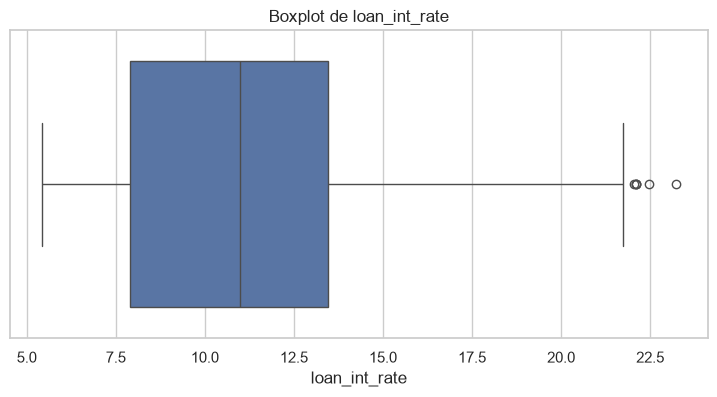

In [358]:
plotar_boxplot(df, "loan_int_rate")

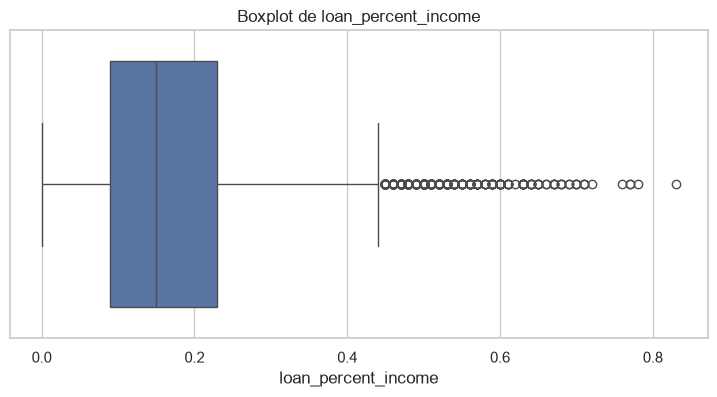

In [359]:
plotar_boxplot(df, "loan_percent_income")

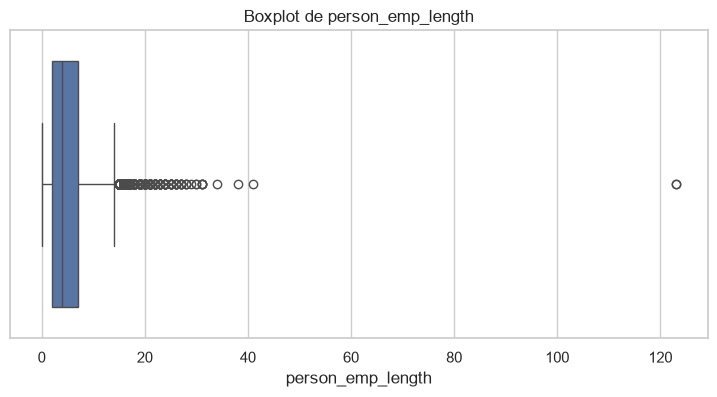

In [360]:
plotar_boxplot(df, "person_emp_length")

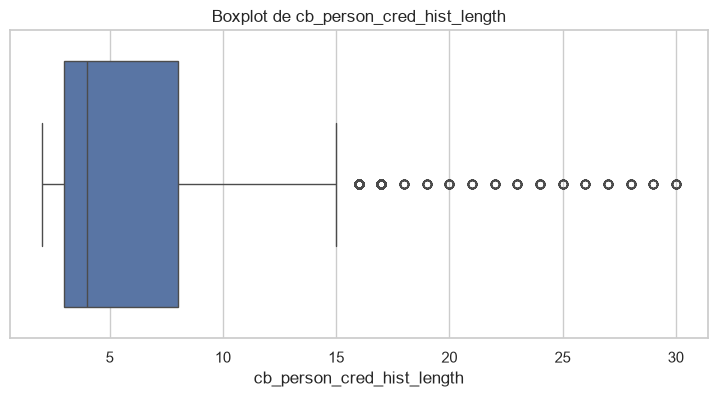

In [361]:
plotar_boxplot(df, "cb_person_cred_hist_length")

função para calcular os limites estatísticos:

In [362]:
def calcular_limites_iqr(dataframe, coluna):
    """
    Calcula os limites inferior e superior pelo método IQR.
    """

    q1 = dataframe[coluna].quantile(0.25)
    q3 = dataframe[coluna].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    return q1, q3, iqr, limite_inferior, limite_superior

testando com uma variável

In [363]:
q1, q3, iqr, limite_inferior, limite_superior = calcular_limites_iqr(
    df,
    "person_income"
)

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")

Q1: 38500.00
Q3: 79200.00
IQR: 40700.00
Limite inferior: -22550.00
Limite superior: 140250.00


função para contar os possíveis outliers

In [364]:
def contar_outliers_iqr(dataframe, coluna):
    """
    Conta valores abaixo e acima dos limites do IQR.
    """

    q1, q3, iqr, limite_inferior, limite_superior = calcular_limites_iqr(
        dataframe,
        coluna
    )

    outliers_inferiores = dataframe[
        dataframe[coluna] < limite_inferior
    ].shape[0]

    outliers_superiores = dataframe[
        dataframe[coluna] > limite_superior
    ].shape[0]

    total_outliers = outliers_inferiores + outliers_superiores

    return {
        "Variável": coluna,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Limite inferior": limite_inferior,
        "Limite superior": limite_superior,
        "Outliers inferiores": outliers_inferiores,
        "Outliers superiores": outliers_superiores,
        "Total de outliers": total_outliers
    }

tabela consolidada de outliers

In [365]:
variaveis_outliers = [
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "person_emp_length",
    "cb_person_cred_hist_length"
]

resultados_outliers = [
    contar_outliers_iqr(df, coluna)
    for coluna in variaveis_outliers
]

tabela_outliers = pd.DataFrame(resultados_outliers)

display(
    tabela_outliers.round(2)
)

,Variável,Q1,Q3,IQR,Limite inferior,Limite superior,Outliers inferiores,Outliers superiores,Total de outliers
0,person_age,23.00,30.00,7.00,12.50,40.50,0,1494,1494
1,person_income,38500.00,79200.00,40700.00,-22550.00,140250.00,0,1484,1484
2,loan_amnt,5000.00,12200.00,7200.00,-5800.00,23000.00,0,1689,1689
3,loan_int_rate,7.90,13.47,5.57,-0.46,21.83,0,6,6
4,loan_percent_income,0.09,0.23,0.14,-0.12,0.44,0,651,651
5,person_emp_length,2.00,7.00,5.00,-5.50,14.50,0,853,853
6,cb_person_cred_hist_length,3.00,8.00,5.00,-4.50,15.50,0,1142,1142


In [366]:
tabela_outliers["Percentual de outliers"] = (
    tabela_outliers["Total de outliers"] / len(df) * 100
).round(2)

display(
    tabela_outliers.round(2)
)

,Variável,Q1,Q3,IQR,Limite inferior,Limite superior,Outliers inferiores,Outliers superiores,Total de outliers,Percentual de outliers
0,person_age,23.00,30.00,7.00,12.50,40.50,0,1494,1494,4.59
1,person_income,38500.00,79200.00,40700.00,-22550.00,140250.00,0,1484,1484,4.55
2,loan_amnt,5000.00,12200.00,7200.00,-5800.00,23000.00,0,1689,1689,5.18
3,loan_int_rate,7.90,13.47,5.57,-0.46,21.83,0,6,6,0.02
4,loan_percent_income,0.09,0.23,0.14,-0.12,0.44,0,651,651,2.00
5,person_emp_length,2.00,7.00,5.00,-5.50,14.50,0,853,853,2.62
6,cb_person_cred_hist_length,3.00,8.00,5.00,-4.50,15.50,0,1142,1142,3.51


In [367]:
decisoes_outliers = pd.DataFrame({
    "Variável": [
        "person_age",
        "person_income",
        "loan_amnt",
        "loan_int_rate",
        "loan_percent_income",
        "person_emp_length",
        "cb_person_cred_hist_length"
    ],

    "Diagnóstico provisório": [
        "Possíveis idades inconsistentes",
        "Valores extremos possivelmente legítimos",
        "Valores altos possivelmente legítimos",
        "Taxas altas plausíveis conforme risco",
        "Valores extremos potencialmente relevantes para inadimplência",
        "Fortes indícios de inconsistência cadastral",
        "Valores elevados plausíveis"
    ],

    "Estratégia provisória": [
        "Investigar registros acima de limite plausível",
        "Manter por enquanto",
        "Manter por enquanto",
        "Manter por enquanto",
        "Manter por relevância preditiva",
        "Investigar e tratar valores impossíveis",
        "Manter"
    ]
})

display(decisoes_outliers)

,Variável,Diagnóstico provisório,Estratégia provisória
0,person_age,Possíveis idades inconsistentes,Investigar registros acima de limite plausível
1,person_income,Valores extremos possivelmente legítimos,Manter por enquanto
2,loan_amnt,Valores altos possivelmente legítimos,Manter por enquanto
3,loan_int_rate,Taxas altas plausíveis conforme risco,Manter por enquanto
4,loan_percent_income,Valores extremos potencialmente relevantes par...,Manter por relevância preditiva
5,person_emp_length,Fortes indícios de inconsistência cadastral,Investigar e tratar valores impossíveis
6,cb_person_cred_hist_length,Valores elevados plausíveis,Manter


### Decisão do Cientista de Dados — Outliers

A análise por boxplots e pelo método IQR identificou valores estatisticamente extremos em diversas variáveis.

Entretanto, nem todo valor extremo representa erro. Variáveis financeiras, como renda, valor do empréstimo e taxa de juros, podem conter valores elevados legítimos e relevantes para o problema de negócio.

As variáveis `person_age` e `person_emp_length` exigem maior atenção, pois valores muito elevados podem representar inconsistências cadastrais.

A variável `loan_percent_income` também apresentou valores extremos, mas esses registros podem ser importantes para identificar clientes com maior risco de inadimplência.

Nenhum outlier será removido automaticamente. A decisão final será baseada na plausibilidade dos valores, no impacto sobre o KNN e na preservação de informações relevantes para a Árvore de Decisão.

### Impacto dos Outliers nos Modelos

O KNN utiliza distâncias entre observações e, por isso, é sensível a valores extremos. Outliers podem alterar significativamente a noção de proximidade entre os clientes.

A Árvore de Decisão é mais robusta a outliers, pois realiza divisões baseadas em limites e regras condicionais.

Por esse motivo, o tratamento de valores extremos será realizado com cautela, evitando a remoção de informações legítimas e relevantes para o risco de crédito.

## 2.7 Correlação entre Variáveis

Nesta etapa será analisada a correlação linear entre as variáveis numéricas por meio do coeficiente de Pearson.

O objetivo é identificar relações lineares relevantes entre os atributos e verificar possíveis indícios de redundância de informações.

selecionando variáveis numericas

In [368]:
variaveis_numericas = df.select_dtypes(include="number")

calculando matriz

In [369]:
matriz_correlacao = variaveis_numericas.corr(
    method="pearson"
)

matriz_correlacao

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


heatmap

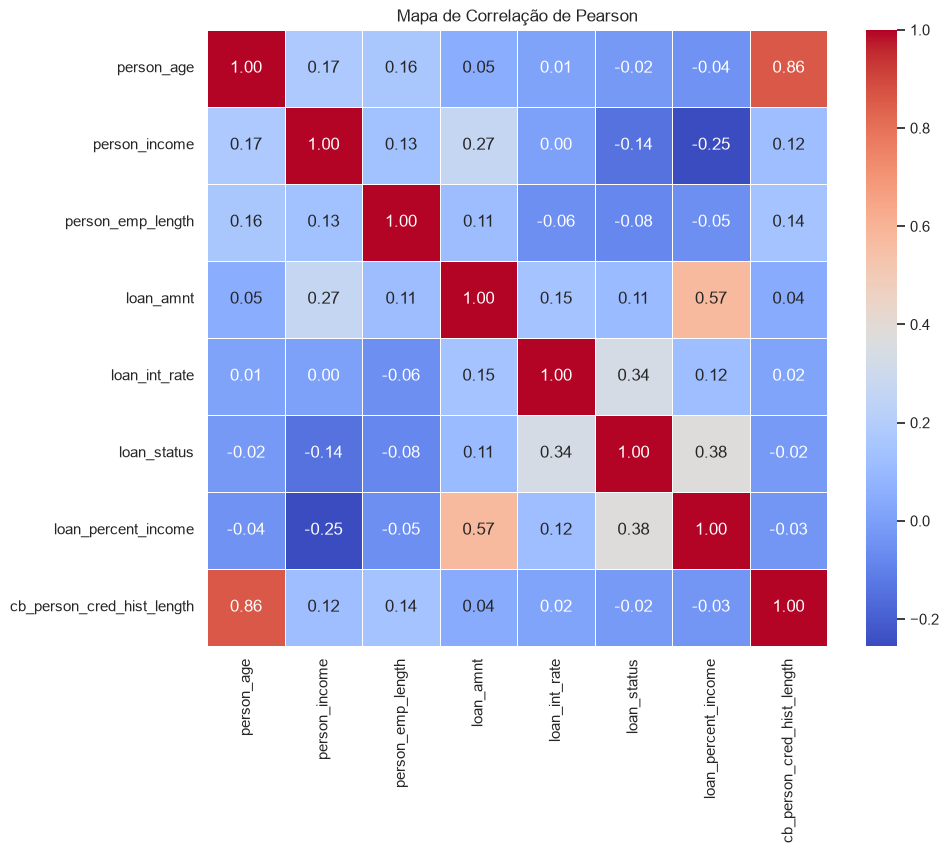

In [370]:
plt.figure(figsize=(10,8))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa de Correlação de Pearson")

plt.show()

criando uma tabela

In [371]:
# Cria uma máscara para manter apenas a parte superior da matriz,
# removendo a diagonal principal e as correlações duplicadas.
mascara_superior = np.triu(
    np.ones(matriz_correlacao.shape),
    k=1
).astype(bool)

# Converte os pares de correlação em uma tabela.
tabela_correlacao = (
    matriz_correlacao
    .where(mascara_superior)
    .stack()
    .reset_index()
)

# Renomeia as colunas.
tabela_correlacao.columns = [
    "Variável 1",
    "Variável 2",
    "Correlação"
]

# Remove correlações ausentes e ordena da maior para a menor.
tabela_correlacao = (
    tabela_correlacao
    .dropna(subset=["Correlação"])
    .sort_values(
        by="Correlação",
        ascending=False
    )
    .reset_index(drop=True)
)

display(tabela_correlacao.round(3))

,Variável 1,Variável 2,Correlação
0,person_age,cb_person_cred_hist_length,0.859
1,loan_amnt,loan_percent_income,0.573
2,loan_status,loan_percent_income,0.379
3,loan_int_rate,loan_status,0.335
4,person_income,loan_amnt,0.267
5,person_age,person_income,0.173
6,person_age,person_emp_length,0.163
7,loan_amnt,loan_int_rate,0.147
8,person_emp_length,cb_person_cred_hist_length,0.145
9,person_income,person_emp_length,0.134


### Tabela de correlações únicas

A matriz de correlação é simétrica, o que significa que a correlação entre duas variáveis aparece duas vezes.

Para evitar duplicidade, foi utilizada apenas a parte superior da matriz, excluindo a diagonal principal.

Os valores ausentes gerados pela máscara triangular foram removidos explicitamente antes da ordenação das correlações.

### Análise da Correlação

O mapa de calor de Pearson permitiu identificar a intensidade das relações lineares entre as variáveis numéricas do conjunto de dados.

A correlação positiva mais elevada foi observada entre `person_age` e `cb_person_cred_hist_length` (0,86), indicando que clientes mais velhos tendem a possuir um histórico de crédito mais longo. Esse comportamento é coerente com o contexto financeiro e não representa uma inconsistência dos dados.

Também foi identificada uma correlação positiva moderada entre `loan_amnt` e `loan_percent_income` (0,57), sugerindo que empréstimos de maior valor tendem a comprometer uma parcela maior da renda do cliente.

Em relação à variável alvo (`loan_status`), as maiores correlações ocorreram com `loan_percent_income` (0,38) e `loan_int_rate` (0,34). Embora essas correlações sejam moderadas, elas indicam que essas variáveis possuem potencial preditivo para identificar clientes com maior probabilidade de inadimplência.

As demais variáveis apresentaram correlações fracas, indicando baixa redundância de informações entre os atributos utilizados pelos modelos de Machine Learning.

### Decisão do Cientista de Dados

A análise de correlação não identificou evidências de multicolinearidade severa entre as variáveis explicativas que justificassem sua remoção nesta etapa.

As correlações observadas são compatíveis com o comportamento esperado para operações de crédito e fornecem informações potencialmente relevantes para os modelos de classificação.

Portanto, todas as variáveis numéricas serão mantidas para as próximas etapas do pipeline, sendo posteriormente avaliadas durante o treinamento dos modelos KNN e Árvore de Decisão.

# 3. Tratamento e Limpeza dos Dados

Após a conclusão da Análise Exploratória, será iniciada a preparação da base.

Nesta etapa serão realizadas as correções necessárias para garantir a qualidade dos dados antes da divisão entre treino e teste.

As decisões serão baseadas nas evidências obtidas durante a EDA, evitando alterações automáticas ou sem justificativa estatística.

preservando base original:

In [372]:
df_tratado = df.copy()

## 3.1 Criação da Base de Trabalho

Foi criada uma cópia do DataFrame original para realizar as etapas de tratamento.

Essa abordagem preserva a base bruta carregada inicialmente e permite comparar os dados antes e depois das transformações.

In [373]:
linhas_antes, colunas_antes = df_tratado.shape

print(f"Linhas antes do tratamento: {linhas_antes}")
print(f"Colunas antes do tratamento: {colunas_antes}")

Linhas antes do tratamento: 32581
Colunas antes do tratamento: 12


## 3.2 Tratamento de Registros Duplicados

Registros completamente duplicados podem aumentar artificialmente a frequência de determinados perfis e introduzir viés durante o treinamento dos modelos.

Por esse motivo, as linhas totalmente duplicadas serão removidas da base de trabalho.

In [374]:
quantidade_duplicados = df_tratado.duplicated().sum()

print(f"Quantidade de registros duplicados: {quantidade_duplicados}")

Quantidade de registros duplicados: 165


In [375]:
df_tratado = df_tratado.drop_duplicates().copy()
#Após operações de filtragem, .copy() cria um DataFrame independente e ajuda a evitar avisos ou alterações ambíguas no pandas.

In [376]:
duplicados_restantes = df_tratado.duplicated().sum()

print(f"Duplicados após o tratamento: {duplicados_restantes}")
print(f"Novo tamanho da base: {df_tratado.shape}")

Duplicados após o tratamento: 0
Novo tamanho da base: (32416, 12)


In [377]:
linhas_depois_duplicados = len(df_tratado)

duplicados_removidos = (
    linhas_antes - linhas_depois_duplicados
)

print(f"Registros removidos: {duplicados_removidos}")

Registros removidos: 165


### Decisão do Cientista de Dados — Duplicatas

As linhas completamente duplicadas foram removidas porque não adicionam novas informações ao conjunto de dados e poderiam aumentar artificialmente a importância de determinados perfis.

A remoção foi aplicada somente à cópia de trabalho, mantendo a base original preservada.

validando valores ausentes

In [378]:
nulos_antes_tratamento = pd.DataFrame({
    "quantidade": df_tratado.isna().sum(),
    "percentual": (
        df_tratado.isna().mean() * 100
    ).round(2)
})

nulos_antes_tratamento = nulos_antes_tratamento[
    nulos_antes_tratamento["quantidade"] > 0
]

nulos_antes_tratamento

,quantidade,percentual
person_emp_length,887,2.74
loan_int_rate,3095,9.55


## Tratamento dos dados

A base original foi preservada e uma cópia de trabalho foi criada para a aplicação das etapas de limpeza.

Os registros completamente duplicados foram removidos para evitar redundância e possível viés estatístico.

## 3.3 Tratamento de Valores Ausentes

Após a análise exploratória, os valores ausentes serão tratados com base no comportamento estatístico de cada variável.

A escolha entre média e mediana será fundamentada na distribuição dos dados e na presença de assimetria e valores extremos.

confirmando nulos

In [379]:
nulos_df_tratado = pd.DataFrame({
    "quantidade": df_tratado.isna().sum(),
    "percentual": (df_tratado.isna().mean() * 100).round(2)
})

nulos_df_tratado = nulos_df_tratado[
    nulos_df_tratado["quantidade"] > 0
]

nulos_df_tratado

,quantidade,percentual
person_emp_length,887,2.74
loan_int_rate,3095,9.55


comparando media e mediana

In [380]:
colunas_com_nulos = nulos_df_tratado.index.tolist()

comparacao_imputacao = pd.DataFrame({
    "media": df_tratado[colunas_com_nulos].mean(),
    "mediana": df_tratado[colunas_com_nulos].median(),
    "assimetria": df_tratado[colunas_com_nulos].skew()
})

comparacao_imputacao.round(2)

,media,mediana,assimetria
person_emp_length,4.79,4.00,2.62
loan_int_rate,11.02,10.99,0.21


### Decisão do Cientista de Dados — Imputação

A variável `person_emp_length` apresentou forte assimetria positiva e valores extremos incompatíveis com o comportamento da maioria dos registros. Por esse motivo, a mediana foi escolhida como técnica de imputação, pois é menos sensível a valores extremos.

A variável `loan_int_rate` apresentou assimetria positiva moderada e alguns valores elevados. A mediana também foi escolhida para preservar uma medida central mais robusta.

A média não foi utilizada porque poderia ser deslocada pelos valores extremos observados durante a EDA.

calculando medianas

In [381]:
mediana_emprego = df_tratado["person_emp_length"].median()
mediana_juros = df_tratado["loan_int_rate"].median()

print(f"Mediana de person_emp_length: {mediana_emprego:.2f}")
print(f"Mediana de loan_int_rate: {mediana_juros:.2f}")

Mediana de person_emp_length: 4.00
Mediana de loan_int_rate: 10.99


imputando

In [382]:
df_tratado["person_emp_length"] = (
    df_tratado["person_emp_length"]
    .fillna(mediana_emprego)
)

df_tratado["loan_int_rate"] = (
    df_tratado["loan_int_rate"]
    .fillna(mediana_juros)
)

validando tratamento

In [383]:
nulos_apos_imputacao = df_tratado[
    ["person_emp_length", "loan_int_rate"]
].isna().sum()

nulos_apos_imputacao

person_emp_length    0
loan_int_rate        0
dtype: int64

validando a base inteira

In [384]:
print(
    f"Total de valores nulos após imputação: "
    f"{df_tratado.isna().sum().sum()}"
)

Total de valores nulos após imputação: 0


comparando antes e depois

In [385]:
resumo_imputacao = pd.DataFrame({
    "variavel": [
        "person_emp_length",
        "loan_int_rate"
    ],
    "metodo": [
        "Mediana",
        "Mediana"
    ],
    "valor_utilizado": [
        mediana_emprego,
        mediana_juros
    ],
    "nulos_restantes": [
        df_tratado["person_emp_length"].isna().sum(),
        df_tratado["loan_int_rate"].isna().sum()
    ]
})

resumo_imputacao.round(2)

,variavel,metodo,valor_utilizado,nulos_restantes
0,person_emp_length,Mediana,4.00,0
1,loan_int_rate,Mediana,10.99,0


### Resultado do Tratamento de Valores Ausentes

Os valores ausentes das variáveis `person_emp_length` e `loan_int_rate` foram preenchidos com suas respectivas medianas.

Após a imputação, não restaram valores ausentes nessas colunas.

A técnica foi escolhida por ser mais robusta diante das assimetrias e dos valores extremos identificados durante a análise exploratória.

## 3.4 Tratamento de Inconsistências Cadastrais

A análise exploratória identificou valores extremos nas variáveis `person_age` e `person_emp_length`.

Nesta etapa serão aplicadas regras de plausibilidade para diferenciar valores extremos legítimos de possíveis erros cadastrais.

As decisões serão baseadas em coerência lógica e conhecimento de negócio.

verificando idade pessoa

In [386]:
df_tratado["person_age"].sort_values(
    ascending=False
).head(20)

32297    144
81       144
183      144
747      123
575      123
32416     94
32506     84
32422     80
32355     78
32534     76
32521     73
32432     73
32381     73
32385     70
32334     70
32383     70
32360     70
32532     70
32522     70
32436     70
Name: person_age, dtype: int64

In [387]:
df_tratado[
    df_tratado["person_age"] > 100
][
    [
        "person_age",
        "person_emp_length",
        "person_income",
        "loan_amnt",
        "loan_status"
    ]
]

,person_age,person_emp_length,person_income,loan_amnt,loan_status
81,144,4.0,250000,4800,0
183,144,4.0,200000,6000,0
575,123,2.0,80004,20400,0
747,123,7.0,78000,20000,0
32297,144,12.0,6000000,5000,0


contanto registros suspeitos de idade

In [388]:
registros_idade_invalida = df_tratado[
    df_tratado["person_age"] > 100
]

print(
    f"Registros com idade acima de 100 anos: "
    f"{len(registros_idade_invalida)}"
)

Registros com idade acima de 100 anos: 5


In [389]:
percentual_idade_invalida = (
    len(registros_idade_invalida) / len(df_tratado) * 100
)

print(
    f"Percentual da base: "
    f"{percentual_idade_invalida:.4f}%"
)

Percentual da base: 0.0154%


investigando tempo de emprego

In [390]:
df_tratado["person_emp_length"].sort_values(
    ascending=False
).head(20)

210      123.0
0        123.0
32355     41.0
32515     38.0
32428     34.0
31866     31.0
31867     31.0
32263     31.0
30914     31.0
32562     30.0
32539     30.0
32480     29.0
32142     28.0
30844     28.0
31203     28.0
31646     27.0
32503     27.0
30646     27.0
32379     27.0
30776     27.0
Name: person_emp_length, dtype: float64

primeira regra de plausibilidade:
O tempo de emprego não pode ser maior do que a idade da pessoa.

In [391]:
registros_emprego_maior_idade = df_tratado[
    df_tratado["person_emp_length"] > df_tratado["person_age"]
]

registros_emprego_maior_idade[
    [
        "person_age",
        "person_emp_length",
        "person_income",
        "loan_status"
    ]
]

,person_age,person_emp_length,person_income,loan_status
0,22,123.0,59000,1
210,21,123.0,192000,0


segunda regra de plausibilidade:
Uma regra razoável é considerar que a pessoa começou a trabalhar, no mínimo, aos 14 anos, entao o tempo de serviço tem que ser menor que a idade -14 


In [392]:
registros_emprego_invalido = df_tratado[
    df_tratado["person_emp_length"] >
    (df_tratado["person_age"] - 14)
]

contando registros inconsistentes

In [393]:
print(
    f"Registros com tempo de emprego incompatível: "
    f"{len(registros_emprego_invalido)}"
)

Registros com tempo de emprego incompatível: 2


In [394]:
percentual_emprego_invalido = (
    len(registros_emprego_invalido) / len(df_tratado) * 100
)

print(
    f"Percentual da base: "
    f"{percentual_emprego_invalido:.4f}%"
)

Percentual da base: 0.0062%


criando mascara consolidada

In [395]:
mascara_inconsistencias = (
    (df_tratado["person_age"] > 100)
    |
    (
        df_tratado["person_emp_length"] >
        (df_tratado["person_age"] - 14)
    )
)

In [396]:
total_inconsistencias = mascara_inconsistencias.sum()

print(
    f"Total de registros inconsistentes: "
    f"{total_inconsistencias}"
)

Total de registros inconsistentes: 7


confirmando regitros inconsistentes

In [397]:
df_tratado.loc[
    mascara_inconsistencias,
    [
        "person_age",
        "person_emp_length",
        "person_income",
        "loan_amnt",
        "loan_status"
    ]
]

,person_age,person_emp_length,person_income,loan_amnt,loan_status
0,22,123.0,59000,35000,1
81,144,4.0,250000,4800,0
183,144,4.0,200000,6000,0
210,21,123.0,192000,20000,0
575,123,2.0,80004,20400,0
747,123,7.0,78000,20000,0
32297,144,12.0,6000000,5000,0


removendo registros inconsistentes

In [398]:
linhas_antes_inconsistencias = len(df_tratado)

df_tratado = df_tratado.loc[
    ~mascara_inconsistencias
].copy()

linhas_depois_inconsistencias = len(df_tratado)

registros_removidos_inconsistencias = (
    linhas_antes_inconsistencias
    - linhas_depois_inconsistencias
)

print(
    f"Registros removidos por inconsistência: "
    f"{registros_removidos_inconsistencias}"
)

Registros removidos por inconsistência: 7


In [399]:
print(
    "Idade máxima após tratamento:",
    df_tratado["person_age"].max()
)

print(
    "Tempo máximo de emprego após tratamento:",
    df_tratado["person_emp_length"].max()
)

Idade máxima após tratamento: 94
Tempo máximo de emprego após tratamento: 41.0


In [400]:
inconsistencias_restantes = (
    df_tratado["person_emp_length"] >
    (df_tratado["person_age"] - 14)
).sum()

print(
    f"Inconsistências restantes: "
    f"{inconsistencias_restantes}"
)

Inconsistências restantes: 0


In [401]:
resumo_inconsistencias = pd.DataFrame({
    "Regra aplicada": [
        "Idade superior a 100 anos",
        "Tempo de emprego maior que idade - 14"
    ],
    "Ação": [
        "Remoção do registro",
        "Remoção do registro"
    ],
    "Justificativa": [
        "Valor considerado implausível para concessão de crédito",
        "Tempo de emprego incompatível com a idade do cliente"
    ]
})

resumo_inconsistencias

,Regra aplicada,Ação,Justificativa
0,Idade superior a 100 anos,Remoção do registro,Valor considerado implausível para concessão d...
1,Tempo de emprego maior que idade - 14,Remoção do registro,Tempo de emprego incompatível com a idade do c...


### Decisão do Cientista de Dados — Inconsistências Cadastrais

Foram identificados registros com idades superiores a 100 anos e casos em que o tempo de emprego era incompatível com a idade do cliente.

Para a variável `person_emp_length`, foi adotada a regra de que o tempo de emprego não pode ser superior à idade do cliente menos 14 anos.

Os registros que violaram essas regras foram removidos, pois representam inconsistências lógicas e não apenas valores estatisticamente extremos.

Essa decisão reduz o risco de distorção das distâncias utilizadas pelo KNN e evita que o modelo aprenda padrões baseados em informações impossíveis.

### Diferença entre Outlier e Inconsistência

Valores extremos em renda, valor do empréstimo ou taxa de juros podem representar situações reais do mercado financeiro e, por isso, não serão removidos automaticamente.

Já valores como idade superior a 100 anos ou tempo de emprego incompatível com a idade foram tratados como inconsistências cadastrais, pois violam regras lógicas do domínio.

## 3.5 Decisão sobre os Outliers Financeiros

In [402]:
decisao_outliers = pd.DataFrame({

    "Variável":[
        "person_income",
        "loan_amnt",
        "loan_int_rate",
        "loan_percent_income"
    ],

    "Possui outliers":[
        "Sim",
        "Sim",
        "Sim",
        "Sim"
    ],

    "Estratégia adotada":[
        "Manter",
        "Manter",
        "Manter",
        "Manter"
    ],

    "Justificativa":[
        "Clientes de alta renda podem representar casos reais.",
        "Empréstimos elevados fazem parte do negócio.",
        "Taxas elevadas podem representar clientes de maior risco.",
        "Comprometimento elevado da renda possui alto potencial preditivo."
    ]
})

display(decisao_outliers)

,Variável,Possui outliers,Estratégia adotada,Justificativa
0,person_income,Sim,Manter,Clientes de alta renda podem representar casos...
1,loan_amnt,Sim,Manter,Empréstimos elevados fazem parte do negócio.
2,loan_int_rate,Sim,Manter,Taxas elevadas podem representar clientes de m...
3,loan_percent_income,Sim,Manter,Comprometimento elevado da renda possui alto p...


### Decisão do Cientista de Dados

Após a análise dos histogramas, boxplots e método IQR, verificou-se que diversas variáveis financeiras apresentaram valores extremos.

Entretanto, diferentemente das inconsistências cadastrais, esses registros representam situações plausíveis dentro do contexto do mercado financeiro.

Clientes com renda elevada, empréstimos de maior valor, taxas de juros superiores e elevado comprometimento da renda constituem perfis importantes para o problema de previsão de inadimplência.

A remoção desses registros reduziria a variabilidade da base e poderia prejudicar a capacidade dos modelos em identificar clientes de maior risco.

Dessa forma, optou-se por manter todos os outliers financeiros.

### Impacto esperado nos modelos

Os outliers financeiros poderão afetar principalmente o algoritmo KNN, uma vez que seu funcionamento depende do cálculo de distâncias entre observações.

Entretanto, posteriormente será aplicado o StandardScaler, reduzindo o impacto das diferentes magnitudes entre as variáveis.

A Árvore de Decisão, por utilizar divisões baseadas em regras condicionais, apresenta maior robustez a valores extremos.

A comparação entre ambos os modelos permitirá verificar experimentalmente o efeito desses registros durante o treinamento.

# 4. Feature Engineering

Nesta etapa será criada uma nova variável numérica a partir de atributos existentes.

A nova característica será chamada `comprometimento_renda` e representará o percentual da renda anual do cliente comprometido pelo valor do empréstimo solicitado.

A criação dessa variável busca fornecer aos modelos uma medida financeira de fácil interpretação e potencialmente relacionada ao risco de inadimplência.

## 4.1 Validação da Renda

Antes da criação da nova variável, será verificado se existem rendas nulas, iguais a zero ou negativas.

Essa validação é necessária para evitar divisões inválidas e a criação de valores infinitos.

In [403]:
validacao_renda = pd.Series({
    "valores_nulos": df_tratado["person_income"].isna().sum(),
    "valores_iguais_zero": (df_tratado["person_income"] == 0).sum(),
    "valores_negativos": (df_tratado["person_income"] < 0).sum(),
    "menor_renda": df_tratado["person_income"].min()
})

validacao_renda

valores_nulos             0
valores_iguais_zero       0
valores_negativos         0
menor_renda            4000
dtype: int64

criando nova variável

In [404]:
df_tratado["comprometimento_renda"] = (
    df_tratado["loan_amnt"]
    / df_tratado["person_income"]
) * 100

In [405]:
df_tratado[
    [
        "loan_amnt",
        "person_income",
        "loan_percent_income",
        "comprometimento_renda"
    ]
].head(10)

,loan_amnt,person_income,loan_percent_income,comprometimento_renda
1,1000,9600,0.10,10.416667
2,5500,9600,0.57,57.291667
3,35000,65500,0.53,53.435115
4,35000,54400,0.55,64.338235
5,2500,9900,0.25,25.252525
6,35000,77100,0.45,45.395590
7,35000,78956,0.44,44.328487
8,35000,83000,0.42,42.168675
9,1600,10000,0.16,16.000000
10,35000,85000,0.41,41.176471


validando nulos e infinitos

In [406]:
quantidade_nulos_comprometimento = (
    df_tratado["comprometimento_renda"]
    .isna()
    .sum()
)

quantidade_infinitos_comprometimento = (
    np.isinf(df_tratado["comprometimento_renda"])
    .sum()
)

print(
    "Valores nulos em comprometimento_renda:",
    quantidade_nulos_comprometimento
)

print(
    "Valores infinitos em comprometimento_renda:",
    quantidade_infinitos_comprometimento
)

Valores nulos em comprometimento_renda: 0
Valores infinitos em comprometimento_renda: 0


In [407]:
df_tratado["comprometimento_renda"].describe()

count    32409.000000
mean        17.059651
std         10.705381
min          0.078947
25%          8.972231
50%         14.814815
75%         22.916667
max         83.000000
Name: comprometimento_renda, dtype: float64

In [408]:
resumo_comprometimento = pd.DataFrame({
    "media": [df_tratado["comprometimento_renda"].mean()],
    "mediana": [df_tratado["comprometimento_renda"].median()],
    "desvio_padrao": [df_tratado["comprometimento_renda"].std()],
    "minimo": [df_tratado["comprometimento_renda"].min()],
    "q1": [df_tratado["comprometimento_renda"].quantile(0.25)],
    "q3": [df_tratado["comprometimento_renda"].quantile(0.75)],
    "maximo": [df_tratado["comprometimento_renda"].max()],
    "assimetria": [df_tratado["comprometimento_renda"].skew()]
})

resumo_comprometimento.round(2)

,media,mediana,desvio_padrao,minimo,q1,q3,maximo,assimetria
0,17.06,14.81,10.71,0.08,8.97,22.92,83.0,1.06


comparando com loan_percent_income

In [409]:
comparacao_comprometimento = df_tratado[
    [
        "loan_percent_income",
        "comprometimento_renda"
    ]
].copy()

comparacao_comprometimento["loan_percent_income_percentual"] = (
    comparacao_comprometimento["loan_percent_income"] * 100
)

comparacao_comprometimento["diferenca"] = (
    comparacao_comprometimento["comprometimento_renda"]
    - comparacao_comprometimento["loan_percent_income_percentual"]
)

comparacao_comprometimento.head(10)

,loan_percent_income,comprometimento_renda,loan_percent_income_percentual,diferenca
1,0.10,10.416667,10.0,0.416667
2,0.57,57.291667,57.0,0.291667
3,0.53,53.435115,53.0,0.435115
4,0.55,64.338235,55.0,9.338235
5,0.25,25.252525,25.0,0.252525
6,0.45,45.395590,45.0,0.395590
7,0.44,44.328487,44.0,0.328487
8,0.42,42.168675,42.0,0.168675
9,0.16,16.000000,16.0,0.000000
10,0.41,41.176471,41.0,0.176471


tamanho das diferenças

In [410]:
comparacao_comprometimento["diferenca"].describe()

count    32409.000000
mean         0.034843
std          0.493361
min         -0.500000
25%         -0.250000
50%          0.000000
75%          0.250000
max          9.338235
Name: diferenca, dtype: float64

In [411]:
correlacao_comprometimento = df_tratado[
    [
        "loan_percent_income",
        "comprometimento_renda"
    ]
].corr()

correlacao_comprometimento

,loan_percent_income,comprometimento_renda
loan_percent_income,1.000000,0.998939
comprometimento_renda,0.998939,1.000000


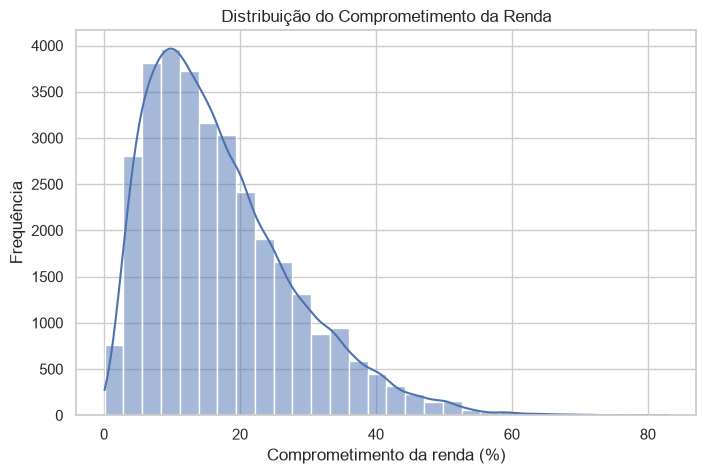

In [412]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_tratado,
    x="comprometimento_renda",
    bins=30,
    kde=True
)

plt.title("Distribuição do Comprometimento da Renda")
plt.xlabel("Comprometimento da renda (%)")
plt.ylabel("Frequência")

plt.show()

### Decisão do Cientista de Dados — Feature Engineering

A variável `comprometimento_renda` foi criada pela divisão entre o valor do empréstimo e a renda anual do cliente, multiplicada por 100.

Antes do cálculo, foi verificada a ausência de rendas nulas, iguais a zero ou negativas, evitando divisões inválidas e valores infinitos.

A nova variável possui interpretação direta: quanto maior o seu valor, maior é a proporção da renda anual comprometida pelo empréstimo.

Foi identificada forte semelhança entre `comprometimento_renda` e a variável original `loan_percent_income`, pois ambas representam essencialmente a mesma informação em escalas diferentes.

Para evitar redundância durante o treinamento, será considerada posteriormente a manutenção de apenas uma dessas variáveis nas entradas dos modelos. Como `comprometimento_renda` foi criada conforme exigência do projeto e está expressa diretamente em percentual, ela será priorizada.

# 5. Divisão dos Dados

Nesta etapa, o conjunto de dados será separado entre variáveis preditoras (`X`) e variável alvo (`y`).

Em seguida, os dados serão divididos em conjuntos de treino e teste, preservando a proporção das classes por meio do parâmetro `stratify`.

O balanceamento e o escalonamento ainda não serão aplicados, pois essas transformações devem ocorrer somente após a separação, evitando vazamento de dados.

verificando colunas disponiveis

In [413]:
df_tratado.columns.tolist()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length',
 'comprometimento_renda']

## 5.1 Definição das Variáveis

A variável `loan_status` será utilizada como alvo do problema de classificação.

A coluna `loan_percent_income` será retirada das variáveis preditoras porque representa praticamente a mesma informação da coluna calculada `comprometimento_renda`.

A manutenção das duas variáveis poderia gerar redundância e atribuir peso duplicado ao comprometimento da renda, principalmente no algoritmo KNN, que utiliza distâncias entre as observações.

criando x e y

In [414]:
X = df_tratado.drop(
    columns=[
        "loan_status",
        "loan_percent_income"
    ]
)

y = df_tratado["loan_status"]

In [415]:
print(f"Dimensões de X: {X.shape}")
print(f"Dimensões de y: {y.shape}")

Dimensões de X: (32409, 11)
Dimensões de y: (32409,)


In [416]:
print("Variável alvo presente em X:", "loan_status" in X.columns)
print(
    "loan_percent_income presente em X:",
    "loan_percent_income" in X.columns
)

print(
    "comprometimento_renda presente em X:",
    "comprometimento_renda" in X.columns
)

Variável alvo presente em X: False
loan_percent_income presente em X: False
comprometimento_renda presente em X: True


verificando a distribuiçao de y

In [417]:
distribuicao_y = pd.DataFrame({
    "quantidade": y.value_counts(),
    "percentual": (
        y.value_counts(normalize=True) * 100
    ).round(2)
})

distribuicao_y

,quantidade,percentual
loan_status,,
0,25321,78.13
1,7088,21.87


fazendo divisao estratificada

In [418]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


verificando tamanhos

In [419]:
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (25927, 11)
X_test: (6482, 11)
y_train: (25927,)
y_test: (6482,)


confirmando estratificação

In [420]:
comparacao_classes = pd.DataFrame({
    "Base completa": (
        y.value_counts(normalize=True) * 100
    ).round(2),

    "Treino": (
        y_train.value_counts(normalize=True) * 100
    ).round(2),

    "Teste": (
        y_test.value_counts(normalize=True) * 100
    ).round(2)
})

comparacao_classes

,Base completa,Treino,Teste
loan_status,,,
0,78.13,78.13,78.12
1,21.87,21.87,21.88


### Decisão do Cientista de Dados — Divisão dos Dados

As variáveis preditoras foram separadas da variável alvo `loan_status`.

A coluna `loan_percent_income` foi retirada das entradas dos modelos por apresentar alta redundância com a coluna calculada `comprometimento_renda`.

Os dados foram divididos em 80% para treinamento e 20% para teste, utilizando `random_state=42` para garantir reprodutibilidade.

O parâmetro `stratify=y` preservou a proporção entre clientes adimplentes e inadimplentes nos dois conjuntos.

Nenhuma técnica de balanceamento ou escalonamento foi aplicada antes da divisão, evitando vazamento de informações do conjunto de teste.

# 6. Pré-processamento dos Dados

Nesta etapa serão aplicadas as transformações necessárias para que os dados possam ser utilizados pelos algoritmos KNN e Árvore de Decisão.

O pré-processamento será ajustado exclusivamente com os dados de treinamento. O conjunto de teste será somente transformado, evitando vazamento de informações.

As principais etapas serão:

1. identificação das variáveis numéricas e categóricas;
2. One-Hot Encoding das variáveis categóricas;
3. balanceamento apenas do conjunto de treinamento;
4. escalonamento das variáveis contínuas exclusivamente para o KNN.

identificando colunas categóricas e numéricas

In [421]:
colunas_categoricas = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

colunas_numericas = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Colunas categóricas:")
print(colunas_categoricas)

print("\nColunas numéricas:")
print(colunas_numericas)

Colunas categóricas:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Colunas numéricas:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length', 'comprometimento_renda']


C:\Users\maycon.valer\AppData\Local\Temp\ipykernel_3192\2304411911.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = X_train.select_dtypes(


verificando categorias

In [422]:
for coluna in colunas_categoricas:
    print(f"\n{coluna}:")
    print(X_train[coluna].value_counts())


person_home_ownership:
person_home_ownership
RENT        13099
MORTGAGE    10715
OWN          2030
OTHER          83
Name: count, dtype: int64

loan_intent:
loan_intent
EDUCATION            5170
MEDICAL              4801
VENTURE              4505
PERSONAL             4411
DEBTCONSOLIDATION    4179
HOMEIMPROVEMENT      2861
Name: count, dtype: int64

loan_grade:
loan_grade
A    8530
B    8281
C    5221
D    2890
E     755
F     196
G      54
Name: count, dtype: int64

cb_person_default_on_file:
cb_person_default_on_file
N    21304
Y     4623
Name: count, dtype: int64


criando codificador

In [423]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
    drop=None
)
#handle_unknown="ignore" -Se o teste possuir uma categoria que não apareceu no treino, o código não falhará.
#sparse_output=False - Retorna uma matriz convencional, mais simples para visualizar e converter em DataFrame.
#drop=None - Mantém todas as categorias. Para KNN e Árvore, isso é aceitável.


ajuste somente no treino

In [424]:
X_train_categorico_encoded = encoder.fit_transform(
    X_train[colunas_categoricas]
)

transformando o teste

In [425]:
X_test_categorico_encoded = encoder.transform(
    X_test[colunas_categoricas]
)

recuperando o nome das nove colunas

In [426]:
nomes_colunas_encoded = encoder.get_feature_names_out(
    colunas_categoricas
)

nomes_colunas_encoded

array(['person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_A',
       'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E',
       'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_N',
       'cb_person_default_on_file_Y'], dtype=object)

convertendo em dataframe

In [427]:
X_train_encoded_df = pd.DataFrame(
    X_train_categorico_encoded,
    columns=nomes_colunas_encoded,
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_categorico_encoded,
    columns=nomes_colunas_encoded,
    index=X_test.index
)
#O index=X_train.index mantém o alinhamento correto entre as linhas.

juntando variaveis numericas e categoricas

In [428]:
X_train_preparado = pd.concat(
    [
        X_train[colunas_numericas].copy(),
        X_train_encoded_df
    ],
    axis=1
)

X_test_preparado = pd.concat(
    [
        X_test[colunas_numericas].copy(),
        X_test_encoded_df
    ],
    axis=1
)

validando encoding

In [429]:
print("Dimensões antes do Encoding:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

print("\nDimensões após o Encoding:")
print(f"X_train_preparado: {X_train_preparado.shape}")
print(f"X_test_preparado: {X_test_preparado.shape}")

Dimensões antes do Encoding:
X_train: (25927, 11)
X_test: (6482, 11)

Dimensões após o Encoding:
X_train_preparado: (25927, 26)
X_test_preparado: (6482, 26)


In [430]:
print(
    "Colunas categóricas restantes no treino:",
    X_train_preparado.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)

Colunas categóricas restantes no treino: []


confirmando que o treino e teste possuem as mesmas colunas

In [431]:
mesmas_colunas = X_train_preparado.columns.equals(
    X_test_preparado.columns
)

print(
    "Treino e teste possuem as mesmas colunas:",
    mesmas_colunas
)

Treino e teste possuem as mesmas colunas: True


validando nulos

In [432]:
print(
    "Nulos no treino preparado:",
    X_train_preparado.isna().sum().sum()
)

print(
    "Nulos no teste preparado:",
    X_test_preparado.isna().sum().sum()
)

Nulos no treino preparado: 0
Nulos no teste preparado: 0


visualizando resultado

In [433]:
X_train_preparado.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
31277,37,85000,19.0,10000,9.99,16,11.764706,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5370,25,50000,7.0,8500,15.70,4,17.000000,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
13355,26,90000,1.0,20000,10.99,3,22.222222,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31860,41,88712,2.0,16000,10.95,15,18.035891,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
24203,35,39000,2.0,10000,13.16,6,25.641026,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 6.1 Encoding das Variáveis Categóricas

As variáveis categóricas foram convertidas em representação numérica utilizando One-Hot Encoding.

O codificador foi ajustado exclusivamente com o conjunto de treinamento por meio de `fit_transform()`. No conjunto de teste foi aplicado somente `transform()`.

Essa separação impede que categorias ou padrões existentes no conjunto de teste influenciem o pré-processamento dos dados de treinamento.

O parâmetro `handle_unknown="ignore"` foi utilizado para permitir que categorias não observadas no treinamento sejam processadas sem interromper a execução do pipeline.

### Decisão do Cientista de Dados — Encoding

Foi utilizado One-Hot Encoding porque as variáveis categóricas não possuem necessariamente uma ordem matemática natural.

A aplicação de Label Encoding poderia atribuir relações ordinais artificiais, como considerar uma categoria maior ou menor que outra.

Após o Encoding, os conjuntos de treino e teste permaneceram com as mesmas colunas e sem valores textuais ou ausentes.

## 6.2 Balanceamento das Classes com SMOTE

A variável alvo apresenta desbalanceamento entre clientes adimplentes e inadimplentes.

Para reduzir o viés do modelo em favor da classe majoritária, será aplicada a técnica SMOTE exclusivamente sobre o conjunto de treinamento.

O conjunto de teste permanecerá inalterado, preservando a distribuição original das classes e permitindo uma avaliação mais próxima do cenário real.

verificando distribuição antes do balanceamento

In [434]:
distribuicao_treino_antes = pd.DataFrame({
    "quantidade": y_train.value_counts(),
    "percentual": (
        y_train.value_counts(normalize=True) * 100
    ).round(2)
})

distribuicao_treino_antes

,quantidade,percentual
loan_status,,
0,20257,78.13
1,5670,21.87


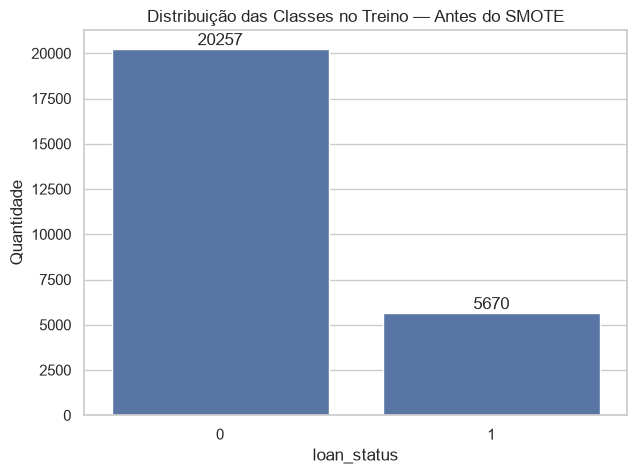

In [435]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(x=y_train)

for barra in ax.patches:
    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(altura)}",
        ha="center",
        va="bottom"
    )

plt.title("Distribuição das Classes no Treino — Antes do SMOTE")
plt.xlabel("loan_status")
plt.ylabel("Quantidade")

plt.show()

criando o balanceador

In [436]:
smote = SMOTE(
    random_state=42
)

#com random_state=42, os resultados serão reproduzíveis.

aplicando somente no treino

In [437]:
X_train_balanceado, y_train_balanceado = smote.fit_resample(
    X_train_preparado,
    y_train
)

verificando tamanhos antes e depois

In [438]:
print("Antes do SMOTE:")
print(f"X_train_preparado: {X_train_preparado.shape}")
print(f"y_train: {y_train.shape}")

print("\nDepois do SMOTE:")
print(f"X_train_balanceado: {X_train_balanceado.shape}")
print(f"y_train_balanceado: {y_train_balanceado.shape}")

print("\nConjunto de teste — inalterado:")
print(f"X_test_preparado: {X_test_preparado.shape}")
print(f"y_test: {y_test.shape}")

Antes do SMOTE:
X_train_preparado: (25927, 26)
y_train: (25927,)

Depois do SMOTE:
X_train_balanceado: (40514, 26)
y_train_balanceado: (40514,)

Conjunto de teste — inalterado:
X_test_preparado: (6482, 26)
y_test: (6482,)


confirmando balanceamento

In [439]:
distribuicao_treino_depois = pd.DataFrame({
    "quantidade": y_train_balanceado.value_counts(),
    "percentual": (
        y_train_balanceado.value_counts(normalize=True) * 100
    ).round(2)
})

distribuicao_treino_depois

,quantidade,percentual
loan_status,,
0,20257,50.0
1,20257,50.0


gráfico apos SMOTE

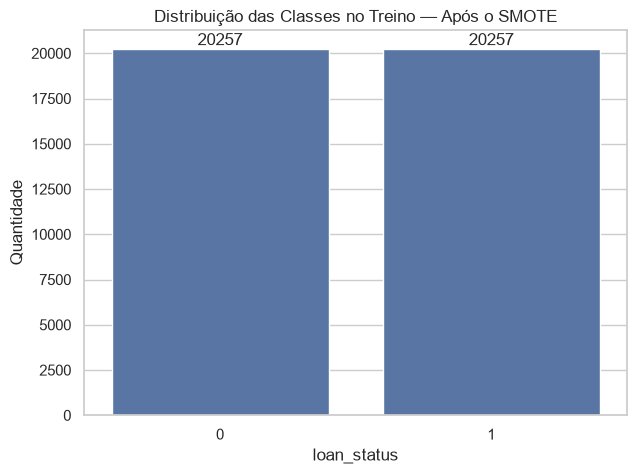

In [440]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(x=y_train_balanceado)

for barra in ax.patches:
    altura = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(altura)}",
        ha="center",
        va="bottom"
    )

plt.title("Distribuição das Classes no Treino — Após o SMOTE")
plt.xlabel("loan_status")
plt.ylabel("Quantidade")

plt.show()

comparando antes e depois em uma tabela

In [441]:
comparacao_balanceamento = pd.DataFrame({
    "Treino antes — quantidade": y_train.value_counts(),
    "Treino antes — percentual": (
        y_train.value_counts(normalize=True) * 100
    ).round(2),

    "Treino após SMOTE — quantidade": (
        y_train_balanceado.value_counts()
    ),

    "Treino após SMOTE — percentual": (
        y_train_balanceado.value_counts(normalize=True) * 100
    ).round(2),

    "Teste original — quantidade": y_test.value_counts(),

    "Teste original — percentual": (
        y_test.value_counts(normalize=True) * 100
    ).round(2)
})

comparacao_balanceamento

,Treino antes — quantidade,Treino antes — percentual,Treino após SMOTE — quantidade,Treino após SMOTE — percentual,Teste original — quantidade,Teste original — percentual
loan_status,,,,,,
0,20257,78.13,20257,50.0,5064,78.12
1,5670,21.87,20257,50.0,1418,21.88


verificando consistencia dos dados balanceados

In [442]:
print(
    "Nulos em X_train_balanceado:",
    X_train_balanceado.isna().sum().sum()
)

print(
    "Nulos em y_train_balanceado:",
    y_train_balanceado.isna().sum()
)

print(
    "Quantidade de colunas após o SMOTE:",
    X_train_balanceado.shape[1]
)

print(
    "Quantidade de colunas antes do SMOTE:",
    X_train_preparado.shape[1]
)

Nulos em X_train_balanceado: 0
Nulos em y_train_balanceado: 0
Quantidade de colunas após o SMOTE: 26
Quantidade de colunas antes do SMOTE: 26


### Por que o SMOTE foi aplicado somente no treino?

O SMOTE cria novos exemplos sintéticos a partir dos registros disponíveis.

Se a técnica fosse aplicada antes da divisão entre treino e teste, os exemplos sintéticos poderiam ser construídos utilizando informações que posteriormente fariam parte do conjunto de teste.

Isso causaria Data Leakage, pois o modelo teria contato indireto com informações da avaliação durante o treinamento.

Por esse motivo, a divisão entre treino e teste foi realizada primeiro, e o SMOTE foi aplicado exclusivamente sobre o conjunto de treinamento.

### Decisão do Cientista de Dados — Balanceamento

O conjunto de treinamento apresentava predominância da classe dos clientes adimplentes.

Foi aplicado SMOTE para aumentar a representatividade da classe dos clientes inadimplentes, reduzindo o risco de o modelo aprender a favorecer somente a classe majoritária.

O conjunto de teste não foi balanceado e manteve sua distribuição original, garantindo uma avaliação realista do desempenho dos modelos.

### Observação técnica

Como o SMOTE foi aplicado após o One-Hot Encoding, as variáveis dummy sintéticas podem assumir valores intermediários entre zero e um.

Essa abordagem é adequada para o escopo do projeto. Em cenários com grande predominância de atributos categóricos, poderia ser considerada a utilização do SMOTENC.

## 6.3 Escalonamento Seguro das Variáveis

O algoritmo KNN utiliza distância euclidiana para determinar os vizinhos mais próximos.

Como variáveis em escalas diferentes podem influenciar excessivamente esse cálculo, será aplicado o StandardScaler exclusivamente ao conjunto destinado ao KNN.

Para a Árvore de Decisão, o escalonamento não será realizado, pois esse algoritmo realiza divisões baseadas em regras condicionais e não depende da magnitude das variáveis.

criando o scaler

In [443]:
scaler = StandardScaler()

ajustando somente o treino balanceado

In [444]:
X_train_knn = scaler.fit_transform(X_train_balanceado)

transformando o teste

In [445]:
X_test_knn = scaler.transform(X_test_preparado)

base da arvore

In [446]:
X_train_tree = X_train_balanceado.copy()

X_test_tree = X_test_preparado.copy()

Validação, as dimensoes devem ser iguais

In [447]:
print("KNN")

print(X_train_knn.shape)
print(X_test_knn.shape)

print()

print("Árvore")

print(X_train_tree.shape)
print(X_test_tree.shape)

KNN
(40514, 26)
(6482, 26)

Árvore
(40514, 26)
(6482, 26)


comprovando que funcionou

In [448]:
X_train_knn_df = pd.DataFrame(
    X_train_knn,
    columns=X_train_preparado.columns
)

X_train_knn_df.describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
count,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.0,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00,40514.00
mean,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,-0.0,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.27,-1.16,-1.22,-1.44,-2.04,-0.94,-1.61,-0.76,-0.07,-0.26,-1.24,-0.5,-0.51,-0.39,-0.53,-0.47,-0.45,-0.62,-0.68,-0.53,-0.51,-0.25,-0.13,-0.08,-2.01,-0.58
25%,-0.76,-0.54,-0.68,-0.76,-0.61,-0.67,-0.81,-0.76,-0.07,-0.26,-1.24,-0.5,-0.51,-0.39,-0.53,-0.47,-0.45,-0.62,-0.68,-0.53,-0.51,-0.25,-0.13,-0.08,-0.22,-0.58
50%,-0.24,-0.20,-0.14,-0.23,-0.07,-0.41,-0.21,-0.76,-0.07,-0.26,0.87,-0.5,-0.51,-0.39,-0.53,-0.47,-0.45,-0.62,-0.68,-0.53,-0.51,-0.25,-0.13,-0.08,0.58,-0.58
75%,0.45,0.25,0.45,0.60,0.74,0.65,0.66,1.42,-0.07,-0.26,0.87,-0.5,-0.51,-0.39,-0.37,-0.47,-0.45,0.92,1.32,-0.53,-0.51,-0.25,-0.13,-0.08,0.58,0.22
max,11.49,41.03,9.05,3.79,3.74,6.44,5.20,1.42,17.80,4.08,0.87,2.3,2.21,2.93,2.15,2.41,2.45,1.74,1.63,2.14,2.32,4.90,9.79,16.11,0.58,2.01


### Decisão do Cientista de Dados

O StandardScaler foi aplicado exclusivamente ao conjunto destinado ao algoritmo KNN.

O ajuste foi realizado apenas sobre os dados de treinamento balanceados (`fit_transform`), enquanto o conjunto de teste foi somente transformado (`transform`), evitando Data Leakage.

Para a Árvore de Decisão, o escalonamento não foi utilizado, pois esse algoritmo realiza divisões condicionais independentes da escala das variáveis.

# 7. Modelagem

Após a preparação dos dados, inicia-se a etapa de treinamento dos modelos de Machine Learning.

Serão avaliados dois algoritmos clássicos de classificação:

- K-Nearest Neighbors (KNN);
- Árvore de Decisão.

Para ambos os modelos serão realizados testes com diferentes hiperparâmetros, comparando simultaneamente o desempenho nos conjuntos de treinamento e teste.

Essa estratégia permitirá identificar sinais de overfitting e selecionar a configuração com maior capacidade de generalização.

criando uma lista para armazenar os resultados.

In [449]:
resultados_modelos = []
#Essa lista será preenchida durante todos os treinamentos. No final ela se transformará em um DataFrame.

resultados_modelos

[]

## Estratégia de Avaliação

Cada configuração dos algoritmos será treinada utilizando o conjunto de treinamento preparado.

Posteriormente serão calculadas as métricas tanto para o conjunto de treinamento quanto para o conjunto de teste.

A comparação entre esses resultados permitirá identificar possíveis sinais de overfitting e selecionar os modelos com melhor capacidade de generalização.

## 7.1 Treinamento Inicial do KNN

O primeiro experimento será realizado utilizando o algoritmo K-Nearest Neighbors com `n_neighbors = 3`.

Essa configuração servirá para validar todo o fluxo de treinamento, predição e avaliação antes da realização dos testes comparativos com outros valores de K.

criando o modelo KNN

In [450]:
knn = KNeighborsClassifier(
    n_neighbors=3
)

treinando o knn com os dados escalonados:

In [451]:
knn.fit(
    X_train_knn,
    y_train_balanceado
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


fazendo as previsões no treino

In [452]:
y_pred_train = knn.predict(
    X_train_knn
)

fazendo as previsões no teste

In [453]:
y_pred_test = knn.predict(
    X_test_knn
)

calculando as acurácias

In [454]:
accuracy_train = accuracy_score(
    y_train_balanceado,
    y_pred_train
)

accuracy_test = accuracy_score(
    y_test,
    y_pred_test
)

In [455]:
print(f"Acurácia Treino: {accuracy_train:.4f}")

print(f"Acurácia Teste : {accuracy_test:.4f}")

Acurácia Treino: 0.9623
Acurácia Teste : 0.8639


calculando a diferença

In [456]:
diferenca = accuracy_train - accuracy_test

print(
    f"Diferença entre treino e teste: {diferenca:.4f}"
)

Diferença entre treino e teste: 0.0984


registrando o resultado

In [457]:
resultados_modelos.append({

    "Modelo":"KNN",

    "Parametro":"K=3",

    "Treino":accuracy_train,

    "Teste":accuracy_test,

    "Diferenca":diferenca

})

In [458]:
pd.DataFrame(resultados_modelos)

,Modelo,Parametro,Treino,Teste,Diferenca
0,KNN,K=3,0.962285,0.863931,0.098354


### Análise do Primeiro Experimento

O primeiro treinamento foi realizado utilizando o algoritmo KNN com três vizinhos.

Foram calculadas as acurácias tanto no conjunto de treinamento quanto no conjunto de teste.

A diferença entre essas métricas será utilizada posteriormente para identificar sinais de overfitting durante a comparação entre diferentes valores do parâmetro `n_neighbors`.

## 7.2 Otimização do KNN

Após validar o fluxo de treinamento, serão realizados experimentos utilizando diferentes valores do hiperparâmetro `n_neighbors`.

Cada configuração será treinada e avaliada tanto no conjunto de treinamento quanto no conjunto de teste.

A comparação simultânea dessas métricas permitirá identificar o melhor equilíbrio entre aprendizado e capacidade de generalização.

apos reset dos valores de resultados_knn, definindo valores de K

In [459]:
resultados_knn = []
valores_k = [3, 5, 7, 9]

automatizando os treinamentos

In [460]:
for k in valores_k:

    modelo = KNeighborsClassifier(
        n_neighbors=k
    )

    modelo.fit(
        X_train_knn,
        y_train_balanceado
    )

    pred_train = modelo.predict(X_train_knn)

    pred_test = modelo.predict(X_test_knn)

    acc_train = accuracy_score(
        y_train_balanceado,
        pred_train
    )

    acc_test = accuracy_score(
        y_test,
        pred_test
    )

    diferenca = acc_train - acc_test

    resultados_knn.append({
        "K": k,
        "Acurácia Treino": acc_train,
        "Acurácia Teste": acc_test,
        "Diferença": diferenca
    })

transformando em DataFrame

In [461]:
resultado_knn_df = pd.DataFrame(
    resultados_knn
)

resultado_knn_df

,K,Acurácia Treino,Acurácia Teste,Diferença
0,3,0.962285,0.863931,0.098354
1,5,0.940662,0.874421,0.066241
2,7,0.925409,0.879821,0.045587
3,9,0.914647,0.883215,0.031432


ordenando

In [462]:
resultado_knn_df = resultado_knn_df.sort_values(
    by="K"
)

resultado_knn_df

,K,Acurácia Treino,Acurácia Teste,Diferença
0,3,0.962285,0.863931,0.098354
1,5,0.940662,0.874421,0.066241
2,7,0.925409,0.879821,0.045587
3,9,0.914647,0.883215,0.031432


Descobrindo melhor K

In [463]:
melhor_knn = resultado_knn_df.loc[
    resultado_knn_df["Acurácia Teste"].idxmax()
]

melhor_knn

K                  9.000000
Acurácia Treino    0.914647
Acurácia Teste     0.883215
Diferença          0.031432
Name: 3, dtype: float64

Grafico

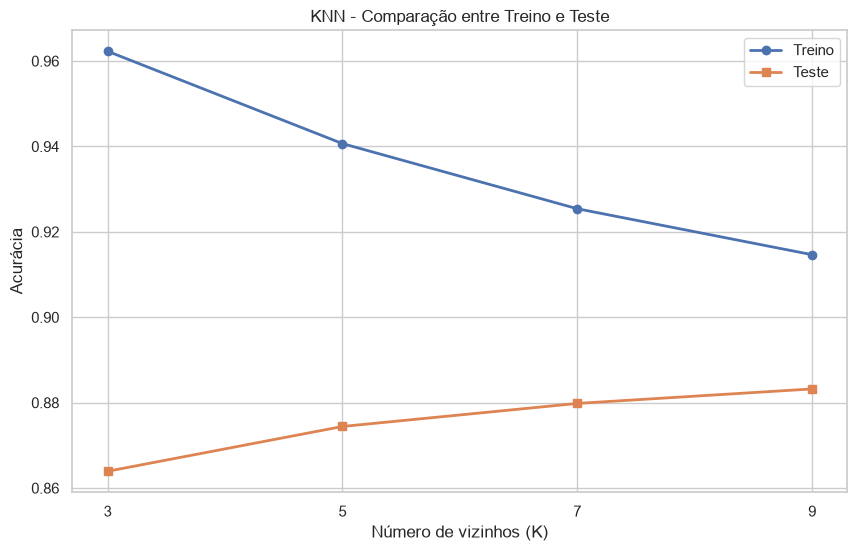

In [464]:
plt.figure(figsize=(10,6))

plt.plot(
    resultado_knn_df["K"],
    resultado_knn_df["Acurácia Treino"],
    marker="o",
    linewidth=2,
    label="Treino"
)

plt.plot(
    resultado_knn_df["K"],
    resultado_knn_df["Acurácia Teste"],
    marker="s",
    linewidth=2,
    label="Teste"
)

plt.xlabel("Número de vizinhos (K)")

plt.ylabel("Acurácia")

plt.title("KNN - Comparação entre Treino e Teste")

plt.xticks(valores_k)

plt.grid(True)

plt.legend()

plt.show()

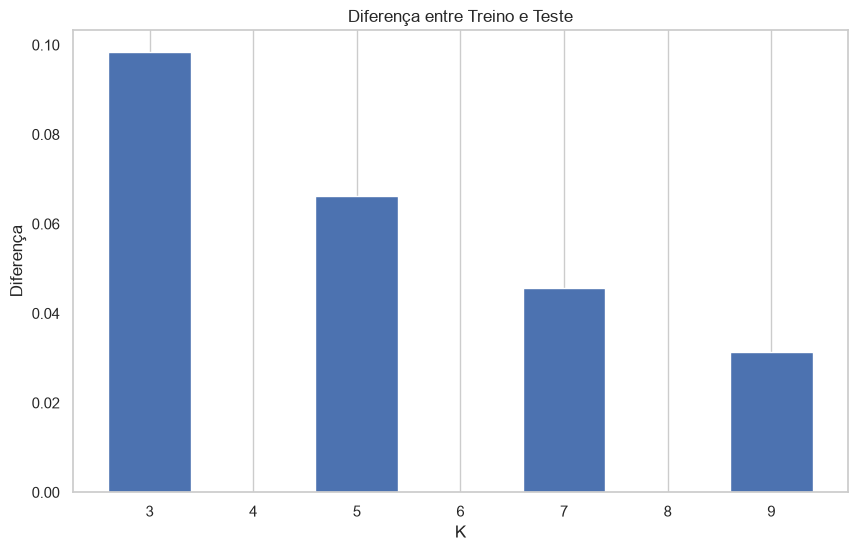

In [465]:
plt.figure(figsize=(10,6))

plt.bar(
    resultado_knn_df["K"],
    resultado_knn_df["Diferença"]
)

plt.xlabel("K")

plt.ylabel("Diferença")

plt.title("Diferença entre Treino e Teste")

plt.grid(axis="y")

plt.show()

### Análise da Otimização do KNN

Foram avaliadas quatro configurações diferentes para o hiperparâmetro `n_neighbors`.

Observou-se que valores menores de K tendem a produzir maior desempenho no treinamento, porém aumentam o risco de overfitting.

À medida que o número de vizinhos aumenta, a diferença entre treino e teste tende a diminuir, indicando melhor capacidade de generalização.

A escolha final será baseada principalmente no desempenho do conjunto de teste aliado à menor diferença entre as duas métricas.

## 7.3 Otimização da Árvore de Decisão

Após a avaliação do algoritmo KNN, será realizada a otimização da Árvore de Decisão.

Serão testadas diferentes profundidades máximas (`max_depth`) para avaliar o impacto da complexidade do modelo sobre a capacidade de generalização.

A comparação entre as métricas de treinamento e teste permitirá identificar o ponto em que a árvore passa a memorizar os dados (overfitting).

criando a lista de resultados

In [466]:
resultados_tree = []

resultados_tree

[]

definindo profundidades

In [467]:
profundidades = [3, 5, 7, None]

automatizando treinamentos

In [468]:
for profundidade in profundidades:

    modelo = DecisionTreeClassifier(
        max_depth=profundidade,
        random_state=42
    )

    modelo.fit(
        X_train_tree,
        y_train_balanceado
    )

    pred_train = modelo.predict(X_train_tree)

    pred_test = modelo.predict(X_test_tree)

    acc_train = accuracy_score(
        y_train_balanceado,
        pred_train
    )

    acc_test = accuracy_score(
        y_test,
        pred_test
    )

    diferenca = acc_train - acc_test

    resultados_tree.append({

        "Profundidade": str(profundidade),

        "Acurácia Treino": acc_train,

        "Acurácia Teste": acc_test,

        "Diferença": diferenca

    })

criando o DataFrame

In [469]:
resultado_tree_df = pd.DataFrame(
    resultados_tree
)

resultado_tree_df

,Profundidade,Acurácia Treino,Acurácia Teste,Diferença
0,3,0.851187,0.877661,-0.026474
1,5,0.894826,0.907590,-0.012764
2,7,0.926371,0.925949,0.000422
3,None,1.000000,0.889540,0.110460


melhor profundidade

In [470]:
melhor_tree = resultado_tree_df.loc[
    resultado_tree_df["Acurácia Teste"].idxmax()
]

melhor_tree

Profundidade              7
Acurácia Treino    0.926371
Acurácia Teste     0.925949
Diferença          0.000422
Name: 2, dtype: object

graficos

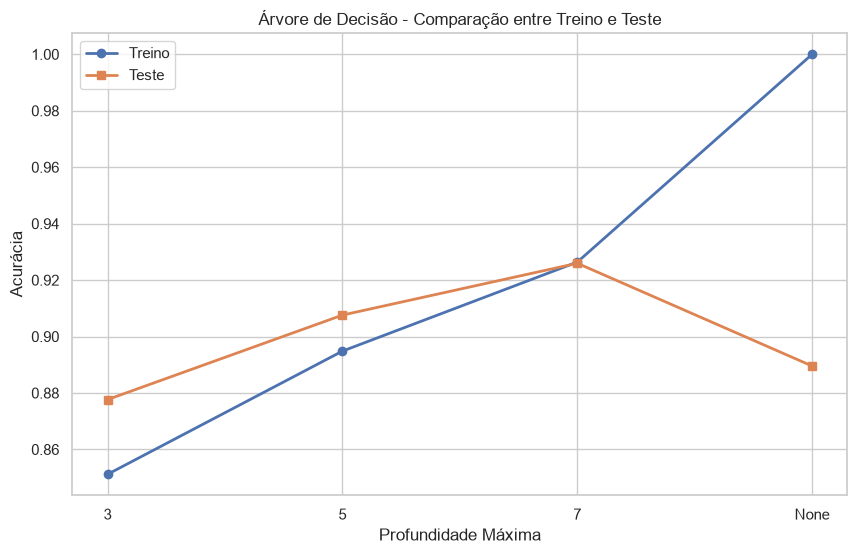

In [471]:
plt.figure(figsize=(10,6))

plt.plot(
    resultado_tree_df["Profundidade"],
    resultado_tree_df["Acurácia Treino"],
    marker="o",
    linewidth=2,
    label="Treino"
)

plt.plot(
    resultado_tree_df["Profundidade"],
    resultado_tree_df["Acurácia Teste"],
    marker="s",
    linewidth=2,
    label="Teste"
)

plt.xlabel("Profundidade Máxima")

plt.ylabel("Acurácia")

plt.title("Árvore de Decisão - Comparação entre Treino e Teste")

plt.grid(True)

plt.legend()

plt.show()

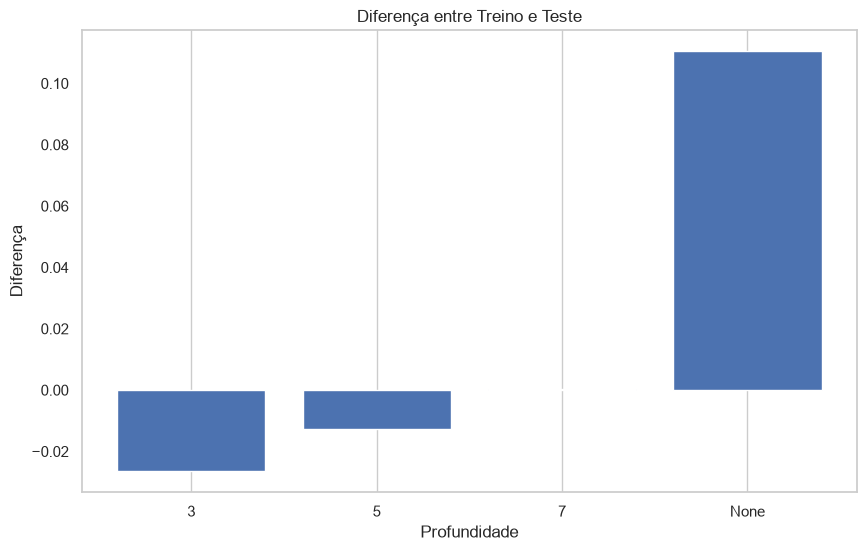

In [472]:
plt.figure(figsize=(10,6))

plt.bar(
    resultado_tree_df["Profundidade"],
    resultado_tree_df["Diferença"]
)

plt.xlabel("Profundidade")

plt.ylabel("Diferença")

plt.title("Diferença entre Treino e Teste")

plt.grid(axis="y")

plt.show()

### Análise da Otimização da Árvore

À medida que a profundidade máxima aumenta, a árvore torna-se mais complexa e passa a representar melhor os dados de treinamento.

Entretanto, árvores excessivamente profundas tendem a memorizar exemplos específicos da base de treinamento, reduzindo sua capacidade de generalização.

A comparação simultânea entre treino e teste permitiu identificar a profundidade que apresentou o melhor equilíbrio entre desempenho e robustez.

## 7.4 Comparação entre os Modelos

Após os experimentos realizados com o KNN e com a Árvore de Decisão, os resultados serão consolidados em uma única tabela.

Essa comparação permitirá selecionar os modelos com melhor desempenho e maior capacidade de generalização para a etapa final de avaliação.

KNN

In [473]:
resultado_knn_df["Modelo"] = "KNN"

resultado_knn_df["Parametro"] = (
    "K=" +
    resultado_knn_df["K"].astype(str)
)

resultado_knn_df = resultado_knn_df[
    [
        "Modelo",
        "Parametro",
        "Acurácia Treino",
        "Acurácia Teste",
        "Diferença"
    ]
]

Arvore

In [474]:
resultado_tree_df["Modelo"] = "Árvore"

resultado_tree_df["Parametro"] = (
    "Depth=" +
    resultado_tree_df["Profundidade"].astype(str)
)

resultado_tree_df = resultado_tree_df[
    [
        "Modelo",
        "Parametro",
        "Acurácia Treino",
        "Acurácia Teste",
        "Diferença"
    ]
]

Unindo

In [475]:
comparacao_modelos = pd.concat(

    [

        resultado_knn_df,

        resultado_tree_df

    ],

    ignore_index=True

)

Ordenando

In [476]:
comparacao_modelos = comparacao_modelos.sort_values(

    by="Acurácia Teste",

    ascending=False

).reset_index(drop=True)

comparacao_modelos

,Modelo,Parametro,Acurácia Treino,Acurácia Teste,Diferença
0,Árvore,Depth=7,0.926371,0.925949,0.000422
1,Árvore,Depth=5,0.894826,0.907590,-0.012764
2,Árvore,Depth=None,1.000000,0.889540,0.110460
3,KNN,K=9,0.914647,0.883215,0.031432
4,KNN,K=7,0.925409,0.879821,0.045587
5,Árvore,Depth=3,0.851187,0.877661,-0.026474
6,KNN,K=5,0.940662,0.874421,0.066241
7,KNN,K=3,0.962285,0.863931,0.098354


Selecionando automaticamente KNN

In [477]:
melhor_knn = comparacao_modelos[
    comparacao_modelos["Modelo"]=="KNN"
].iloc[0]

melhor_knn

Modelo                  KNN
Parametro               K=9
Acurácia Treino    0.914647
Acurácia Teste     0.883215
Diferença          0.031432
Name: 3, dtype: object

Selecionando automaticamente Arvore

In [478]:
melhor_tree = comparacao_modelos[
    comparacao_modelos["Modelo"]=="Árvore"
].iloc[0]

melhor_tree

Modelo               Árvore
Parametro           Depth=7
Acurácia Treino    0.926371
Acurácia Teste     0.925949
Diferença          0.000422
Name: 0, dtype: object

Grafico comparativo

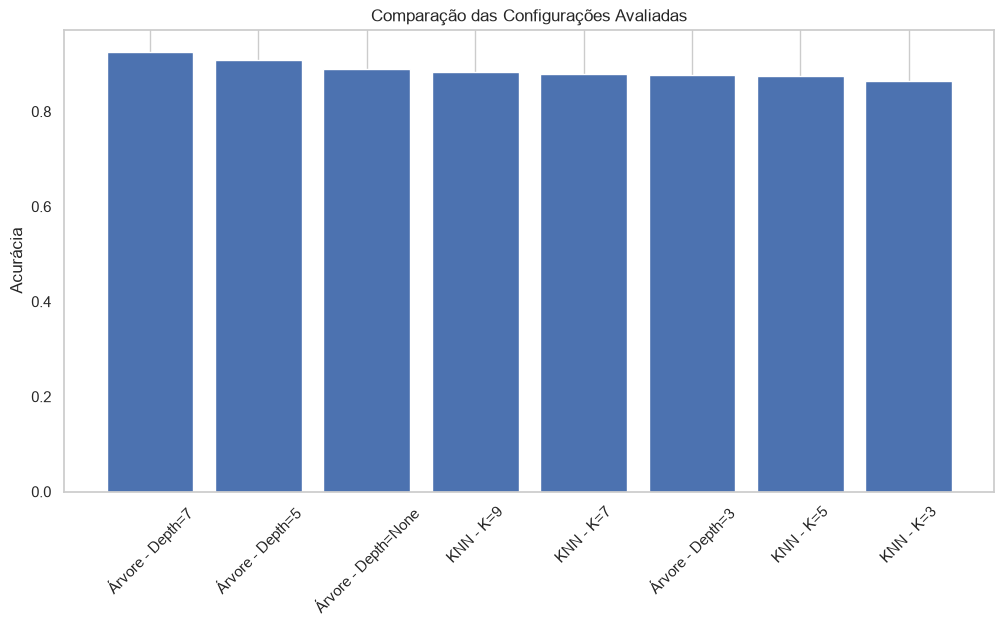

In [479]:
plt.figure(figsize=(12,6))

plt.bar(

    comparacao_modelos["Modelo"] +

    " - " +

    comparacao_modelos["Parametro"],

    comparacao_modelos["Acurácia Teste"]

)

plt.xticks(rotation=45)

plt.ylabel("Acurácia")

plt.title("Comparação das Configurações Avaliadas")

plt.grid(axis="y")

plt.show()

Grafico do Overfitting

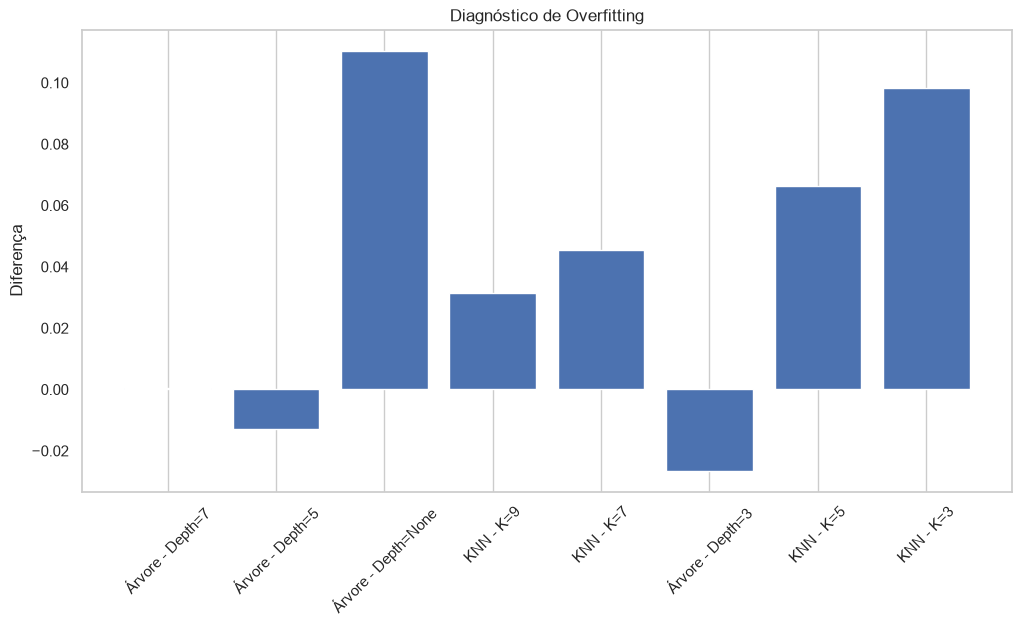

In [480]:
plt.figure(figsize=(12,6))

plt.bar(

    comparacao_modelos["Modelo"]

    + " - "

    + comparacao_modelos["Parametro"],

    comparacao_modelos["Diferença"]

)

plt.xticks(rotation=45)

plt.ylabel("Diferença")

plt.title("Diagnóstico de Overfitting")

plt.grid(axis="y")

plt.show()

### Comparação entre os Modelos

Todos os experimentos foram consolidados em uma única tabela.

A seleção dos melhores modelos considerou dois critérios:

- maior acurácia no conjunto de teste;
- menor diferença entre treino e teste.

Esse procedimento permite identificar modelos que apresentam não apenas elevado desempenho, mas também boa capacidade de generalização.

# 8. Avaliação Final

Nesta etapa serão avaliadas apenas as melhores configurações identificadas durante a fase de otimização.

Serão utilizados o Classification Report e a Matriz de Confusão para analisar o comportamento dos modelos sob a perspectiva estatística e de negócio.

O objetivo é selecionar o algoritmo que apresenta melhor equilíbrio entre desempenho e impacto financeiro para o banco.

recuperando melhor K

In [481]:
melhor_k = int(
    melhor_knn["Parametro"]
    .replace("K=", "")
)

print(melhor_k)

9


Recuperando melhor profundidade

In [482]:
valor_depth = melhor_tree["Parametro"].replace(
    "Depth=",
    ""
)

if valor_depth == "None":
    melhor_depth = None
else:
    melhor_depth = int(valor_depth)

print(melhor_depth)

7


treinando novamente o melhor KNN

In [483]:
knn_final = KNeighborsClassifier(
    n_neighbors=melhor_k
)

knn_final.fit(
    X_train_knn,
    y_train_balanceado
)

pred_knn = knn_final.predict(
    X_test_knn
)

Treinando novamente a melhor Árvore

In [484]:
tree_final = DecisionTreeClassifier(

    max_depth=melhor_depth,

    random_state=42

)

tree_final.fit(

    X_train_tree,

    y_train_balanceado

)

pred_tree = tree_final.predict(

    X_test_tree

)

Classification Report

In [485]:
print("========== KNN ==========\n")

print(

    classification_report(

        y_test,

        pred_knn

    )

)

========== KNN ==========

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      5064
           1       0.76      0.68      0.72      1418

    accuracy                           0.88      6482
   macro avg       0.84      0.81      0.82      6482
weighted avg       0.88      0.88      0.88      6482



In [486]:
print("========== Árvore ==========\n")

print(

    classification_report(

        y_test,

        pred_tree

    )

)

========== Árvore ==========

              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5064
           1       0.94      0.71      0.81      1418

    accuracy                           0.93      6482
   macro avg       0.93      0.85      0.88      6482
weighted avg       0.93      0.93      0.92      6482



Matriz de Confusão

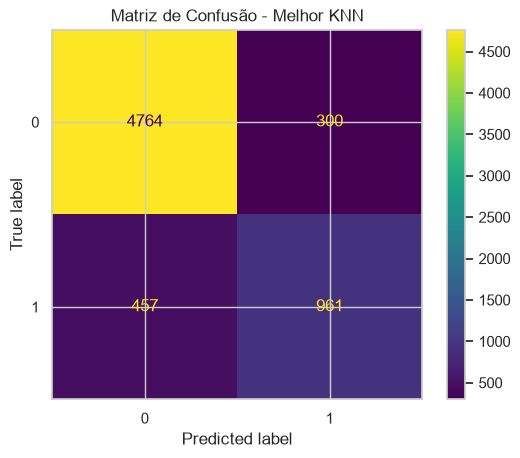

In [487]:
cm_knn = confusion_matrix(

    y_test,

    pred_knn

)

ConfusionMatrixDisplay(

    confusion_matrix=cm_knn

).plot()

plt.title(

    "Matriz de Confusão - Melhor KNN"

)

plt.show()

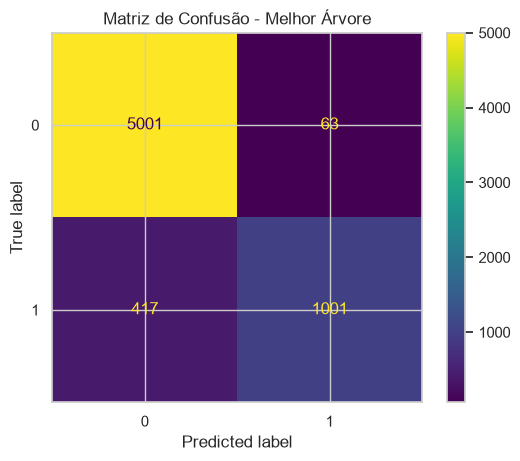

In [488]:
cm_tree = confusion_matrix(

    y_test,

    pred_tree

)

ConfusionMatrixDisplay(

    confusion_matrix=cm_tree

).plot()

plt.title(

    "Matriz de Confusão - Melhor Árvore"

)

plt.show()

Extraindo automaticamente KNN

In [489]:
tn, fp, fn, tp = cm_knn.ravel()

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

TN: 4764
FP: 300
FN: 457
TP: 961


Extraindo automaticamente Árvore

In [490]:
tn2, fp2, fn2, tp2 = cm_tree.ravel()

print(f"TN: {tn2}")
print(f"FP: {fp2}")
print(f"FN: {fn2}")
print(f"TP: {tp2}")

TN: 5001
FP: 63
FN: 417
TP: 1001


## Interpretação dos Resultados

A Matriz de Confusão permitiu identificar a quantidade de clientes corretamente classificados e os erros cometidos pelos modelos.

Especial atenção foi dada aos Falsos Positivos e Falsos Negativos, pois esses erros possuem impactos financeiros distintos para a instituição bancária.

Enquanto os Falsos Positivos representam oportunidades de negócio perdidas, os Falsos Negativos correspondem à concessão de crédito para clientes inadimplentes, ocasionando prejuízos diretos ao banco.

# 9. Veredito Final

Após todas as etapas de preparação dos dados, otimização dos modelos e avaliação estatística, será realizada a análise final sob a perspectiva do negócio.

A decisão não será baseada exclusivamente na acurácia, mas também na capacidade de generalização do modelo e no impacto financeiro decorrente dos erros de classificação.

montando tabela acurácia final

In [491]:
comparacao_final = pd.DataFrame({

    "Modelo":[
        "Melhor KNN",
        "Melhor Árvore"
    ],

    "Parâmetro":[
        melhor_knn["Parametro"],
        melhor_tree["Parametro"]
    ],

    "Accuracy Teste":[
        melhor_knn["Acurácia Teste"],
        melhor_tree["Acurácia Teste"]
    ],

    "Diferença Treino/Teste":[
        melhor_knn["Diferença"],
        melhor_tree["Diferença"]
    ]

})

comparacao_final

,Modelo,Parâmetro,Accuracy Teste,Diferença Treino/Teste
0,Melhor KNN,K=9,0.883215,0.031432
1,Melhor Árvore,Depth=7,0.925949,0.000422


tabela mostrando dos erros final

In [492]:
impacto_negocio = pd.DataFrame({

    "Modelo":[
        "Melhor KNN",
        "Melhor Árvore"
    ],

    "Falsos Positivos":[
        fp,
        fp2
    ],

    "Falsos Negativos":[
        fn,
        fn2
    ]

})

impacto_negocio

,Modelo,Falsos Positivos,Falsos Negativos
0,Melhor KNN,300,457
1,Melhor Árvore,63,417


## Impacto Financeiro

No contexto de concessão de crédito, os Falsos Negativos representam o erro mais crítico para o banco.

Esse erro ocorre quando um cliente inadimplente é classificado como um bom pagador, ocasionando a aprovação de um empréstimo com elevada probabilidade de prejuízo financeiro.

Os Falsos Positivos também possuem impacto econômico, pois bons clientes podem deixar de receber crédito. Entretanto, esse prejuízo costuma ser inferior ao risco de inadimplência decorrente dos Falsos Negativos.

## Veredito Executivo

Após a comparação entre o KNN com `K=9` e a Árvore de Decisão com `max_depth=7`, recomenda-se a utilização da **Árvore de Decisão** como modelo final para o problema de risco de crédito.

A Árvore apresentou acurácia de aproximadamente **92,59%** no conjunto de teste, superando os **88,32%** obtidos pelo KNN. Além disso, a diferença entre as acurácias de treino e teste foi de apenas **0,04 ponto percentual**, indicando excelente capacidade de generalização e ausência de sinais relevantes de overfitting.

Sob a perspectiva de negócio, a Árvore também apresentou resultados superiores na Matriz de Confusão. O modelo registrou **63 falsos positivos**, contra 300 do KNN, e **417 falsos negativos**, contra 457 do KNN.

No contexto bancário, os falsos negativos representam o erro mais crítico, pois correspondem a clientes inadimplentes classificados como bons pagadores. Esse erro pode resultar na concessão de empréstimos com alto risco de não pagamento e gerar prejuízo financeiro direto para a instituição.

Embora a redução de falsos negativos da Árvore em relação ao KNN tenha sido moderada, a Árvore apresentou simultaneamente maior acurácia, menor diferença entre treino e teste e redução expressiva dos falsos positivos.

Dessa forma, a **Árvore de Decisão com profundidade máxima igual a 7** apresentou o melhor equilíbrio entre desempenho estatístico, capacidade de generalização e impacto financeiro, sendo o modelo recomendado para implantação.

## Limitações do Modelo

Apesar dos resultados obtidos, o modelo ainda apresenta limitações.

Entre elas destacam-se:

- utilização de uma única base histórica;
- possíveis mudanças no comportamento financeiro dos clientes ao longo do tempo;
- necessidade de monitoramento contínuo após implantação;
- possibilidade de recalibração periódica dos hiperparâmetros.

# Checklist Técnico do Projeto

- [x] Tamanho da base exibido
- [x] Tipos das variáveis analisados
- [x] Estatística descritiva com `describe()`
- [x] Registros duplicados investigados e tratados
- [x] Valores ausentes investigados e imputados
- [x] Outliers investigados com histogramas, boxplots e IQR
- [x] Distribuição da variável alvo analisada
- [x] Mapa de correlação de Pearson criado
- [x] Feature Engineering realizada
- [x] Divisão estratificada entre treino e teste
- [x] Encoding ajustado somente no treino
- [x] SMOTE aplicado somente no treino
- [x] StandardScaler aplicado somente ao KNN
- [x] Árvore treinada sem escalonamento
- [x] Quatro valores de K avaliados
- [x] Quatro profundidades da Árvore avaliadas
- [x] Overfitting analisado com treino e teste
- [x] Classification Reports gerados
- [x] Matrizes de Confusão geradas
- [x] Falsos Positivos e Falsos Negativos interpretados
- [x] Veredito de negócio documentado